## Import

In [1]:
from tqdm import tqdm

import numpy as np
from numpy.typing import NDArray
from numba import njit
from numba import set_num_threads
set_num_threads(28)

from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle

from domain.scan import iterate
from domain.scan import count
from domain.scan import scan
from domain.scan import orbit

from domain.da import da
from domain.da import refine

from domain.volume import rays
from domain.volume import directions
from domain.volume import volume

from domain.sample import sample
from domain.sample import mask
from domain.sample import filter
from domain.sample import select
from domain.domain import Domain

from domain import Configuration
from domain import Result
from domain import compute

## Henon map (2D & 4D)

In [2]:
@njit
def forward2d(
    x: NDArray[np.float64],
    parameters: NDArray[np.float64],
) -> NDArray[np.float64]:
    """
    Forward 2D Henon symplectic mapping in McMillan form

    Parameters
    ----------
    x: NDArray[np.float64], shape (dimension,)
        phase-space coordinates
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    q, p = x
    a, b = parameters
    Q = p
    P = -q + a*p + (1.0 - b)*p**2 + b*p**3
    return np.array([Q, P], dtype=np.float64)


@njit
def inverse2d(
    x: NDArray[np.float64],
    parameters: NDArray[np.float64],
) -> NDArray[np.float64]:
    """
    Inverse 2D Henon symplectic mapping in McMillan form

    Parameters
    ----------
    x: NDArray[np.float64], shape (dimension,)
        phase-space coordinates
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    q, p = x
    a, b = parameters
    Q = -p + a*q + (1.0 - b)*q**2 + b*q**3
    P = q
    return np.array([Q, P], dtype=np.float64)


@njit
def forward4d(
    x:NDArray[np.float64], 
    parameters:NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    Forward 4D Henon symplectic mapping

    Parameters
    ----------
    x: NDArray[np.float64], (dimension, )
        initial condition
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    qx, qy, px, py = x
    cx, sx, cy, sy, mu = parameters
    Qx = cx*qx + sx*(px + qx**2 - qy**2 + mu*(qx**3 - 3*qx*qy**2))
    Qy = cy*qy + sy*(py - 2*qx*qy + mu*(-3*qx**2*qy + qy**3))
    Px = cx*(px + qx**2 - qy**2 + mu*(qx**3 - 3*qx*qy**2)) - sx*qx
    Py = cy*(py - 2*qx*qy + mu*(-3*qx**2*qy + qy**3)) - sy*qy
    return np.array([Qx, Qy, Px, Py])


@njit
def inverse4d(
    x: NDArray[np.float64], 
    parameters: NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    Accelerator mapping (Henon) symplectic mapping (inverse)

    Parameters
    ----------
    x: NDArray[np.float64], (dimension, )
        initial condition
    parameters: NDArray[np.float64]
        mapping parameters

    Returns
    -------
    NDArray[np.float64]

    """
    qx, qy, px, py = x
    cx, sx, cy, sy, mu = parameters
    Qx = cx*qx - sx*px
    Qy = cy*qy - sy*py
    Px = cx*px + sx*qx - Qx**2 + Qy**2 - mu*(Qx**3 - 3*Qx*Qy**2)
    Py = cy*py + sy*qy + 2*Qx*Qy - mu*(-3*Qx**2*Qy + Qy**3)
    return np.array([Qx, Qy, Px, Py])

In [3]:
# Test (2D)

a, b = 0.4678, 0.0
knobs = np.asarray([a, b])
state = np.array([0.05, -0.01])
print(state)
print(inverse2d(forward2d(state, knobs), knobs))
print()

a, b = -0.065, 0.0
knobs = np.asarray([a, b])
state = np.array([0.05, -0.01])
print(state)
print(inverse2d(forward2d(state, knobs), knobs))
print()

[ 0.05 -0.01]
[ 0.05 -0.01]

[ 0.05 -0.01]
[ 0.05 -0.01]



In [4]:
# Test (4D)

nux, nuy = 0.280, 0.310
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.05, -0.05, 0.01, 0.01])
print(state)
print(inverse4d(forward4d(state, knobs), knobs))
print()


nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.05, -0.05, 0.01, 0.01])
print(state)
print(inverse4d(forward4d(state, knobs), knobs))
print()

[ 0.05 -0.05  0.01  0.01]
[ 0.05 -0.05  0.01  0.01]

[ 0.05 -0.05  0.01  0.01]
[ 0.05 -0.05  0.01  0.01]



## Escape: Phase space trajectories (2D)

In [5]:
# Set initial conditions along the diagonal symmetry line

m = 128
qs = np.linspace(0.0, 2.0, m)
ps = np.copy(qs)
xs = np.stack([qs, ps]).T

print(xs.shape)

(128, 2)


In [6]:
# Set orbit container

n = 2**10
os = np.full((m, n, 1 + 1), fill_value=np.nan)

In [7]:
# Set map parameters

r = 100.0

a, b = 0.4678, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [8]:
# Compute full orbits

scan(xs, os, orbit(n, r, forward2d), knobs)

In [9]:
# Set non-escaping and escaping orbits

os_a = os[np.logical_not(np.isnan(os.sum((1, -1))))]
os_b = os[np.isnan(os.sum((1, -1)))]

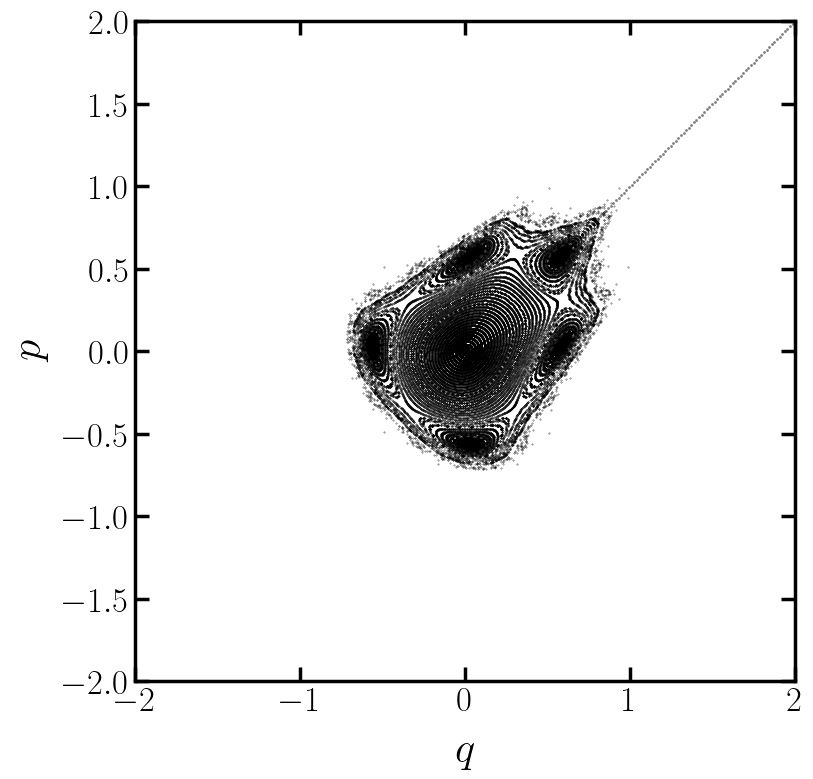

In [10]:
# Plot non-escaping phase space trajectories

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.scatter(*xs.T, s=1, marker="o", c="grey", alpha=1.0, zorder=0)
ax.scatter(*os_a.reshape(-1, 1 + 1).T, s=0.1, marker="o", c="black", alpha=0.75, zorder=1)
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25*fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25*fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75*tick_width, length=0.75*tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

In [11]:
# Compute full orbits (inverse)

scan(xs, os, orbit(n, r, inverse2d), knobs)

In [12]:
# Set non-escaping and escaping orbits

os_a_inverse = os[np.logical_not(np.isnan(os.sum((1, -1))))]
os_b_inverse = os[np.isnan(os.sum((1, -1)))]

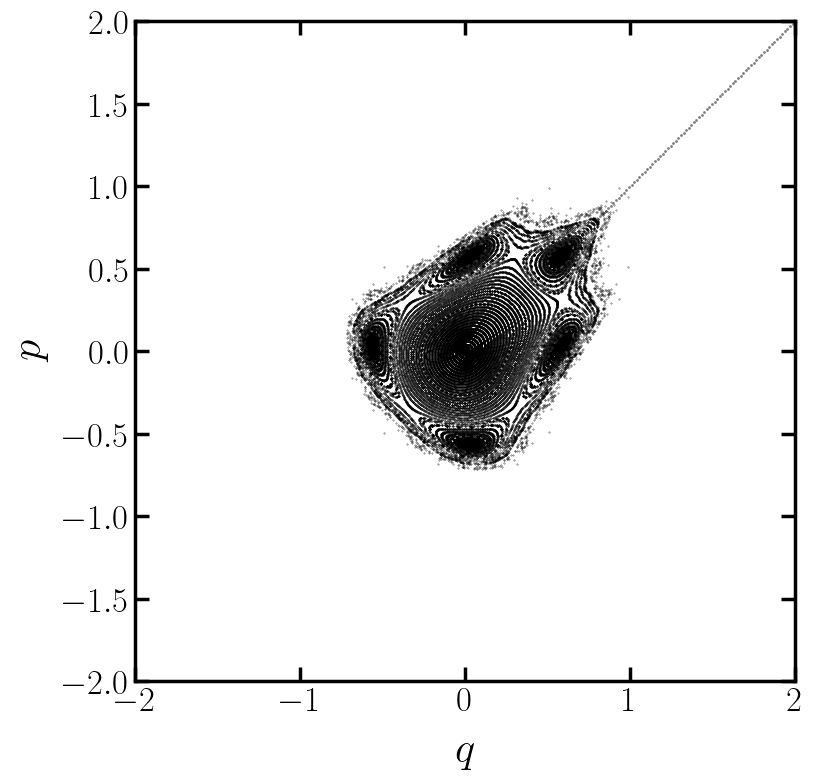

In [13]:
# Plot non-escaping phase space trajectories (inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.scatter(*xs.T, s=1, marker="o", c="grey", alpha=1.0, zorder=0)
ax.scatter(*os_a_inverse.reshape(-1, 1 + 1).T, s=0.1, marker="o", c="black", alpha=0.75, zorder=1)
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25*fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25*fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75*tick_width, length=0.75*tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

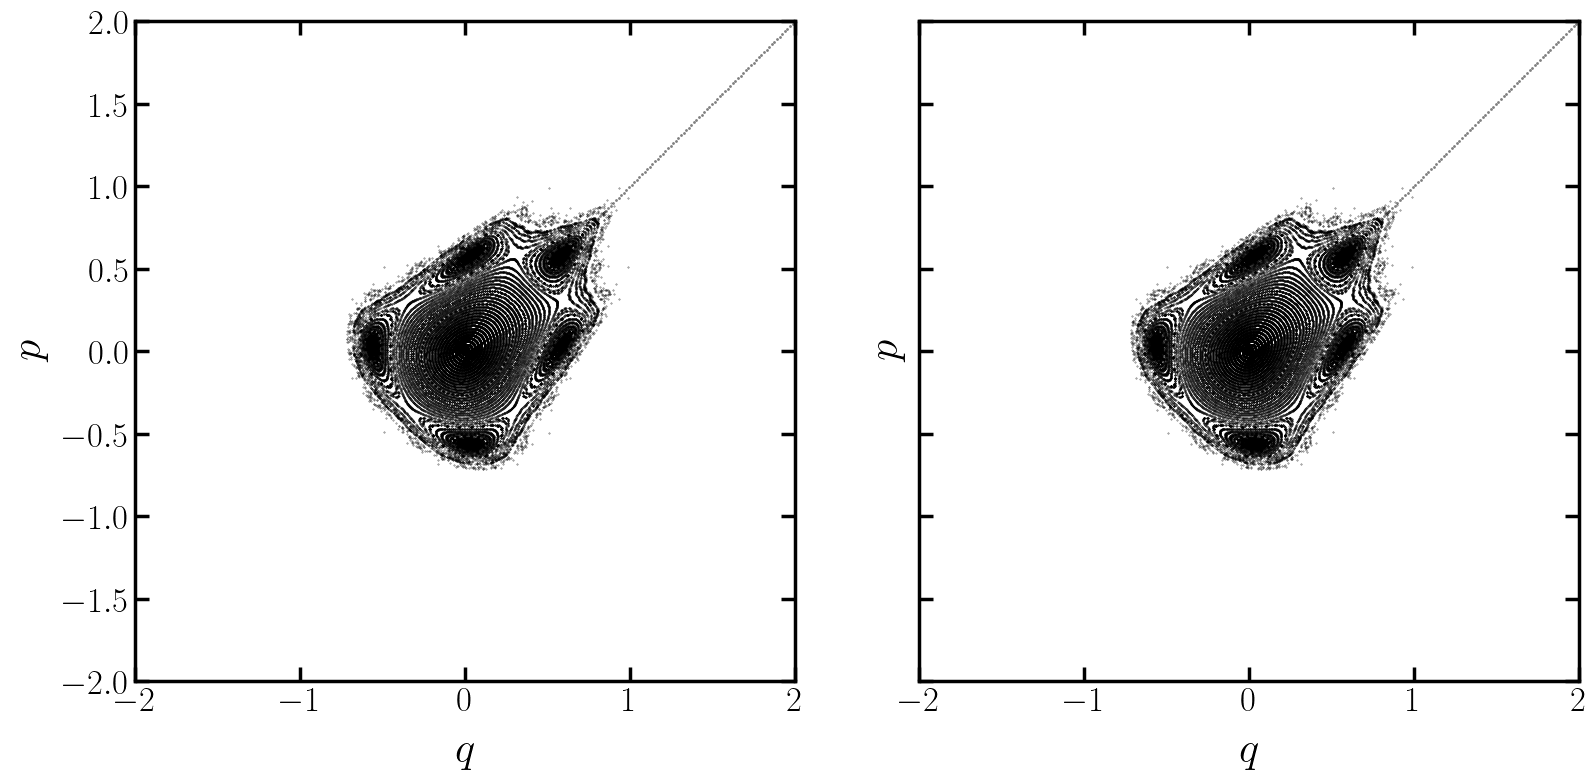

In [14]:
# Plot non-escaping phase space trajectories (forward vs inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, (ax, ay) = plt.subplots(1, 2, figsize=(16.0, 8.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.080, right=0.985, bottom=0.150, top=0.975, wspace=0.18)

ax.scatter(*xs.T, s=1, marker="o", c="grey", alpha=1.0, zorder=0)
ax.scatter(*os_a.reshape(-1, 2).T, s=0.1, marker="o", c="black", alpha=0.75, zorder=1)
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)

ay.scatter(*xs.T, s=1, marker="o", c="grey", alpha=1.0, zorder=0)
ay.scatter(*os_a_inverse.reshape(-1, 2).T, s=0.1, marker="o", c="black", alpha=0.75, zorder=1)
ay.set_xlim(-2.0, 2.0)
ay.set_ylim(-2.0, 2.0)
ay.set_aspect("equal", adjustable="box")
ay.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ay.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ay.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ay.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ay.spines.values():
    spine.set_linewidth(spine_width)

plt.show()

## Escape: Phase space trajectories (2D & alternative knob values)

In [15]:
# Set initial conditions along the diagonal symmetry line

m = 128
qs = np.linspace(0.0, 2.0, m)
ps = np.copy(qs)
xs = np.stack([qs, ps]).T

print(xs.shape)

(128, 2)


In [16]:
# Set orbit container

n = 2**10
os = np.full((m, n, 1 + 1), fill_value=np.nan)

In [17]:
# Set map parameters

r = 100.0

a, b = -0.065, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [18]:
# Compute full orbits

scan(xs, os, orbit(n, r, forward2d), knobs)

In [19]:
# Set non-escaping and escaping orbits

os_a = os[np.logical_not(np.isnan(os.sum((1, -1))))]
os_b = os[np.isnan(os.sum((1, -1)))]

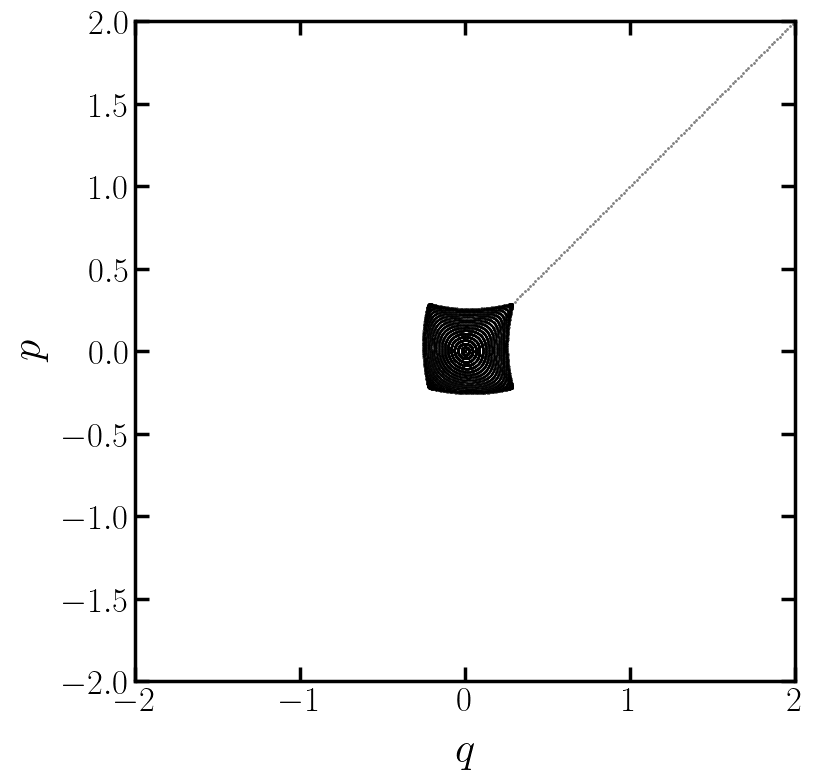

In [20]:
# Plot non-escaping phase space trajectories

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.scatter(*xs.T, s=1, marker="o", c="grey", alpha=1.0, zorder=0)
ax.scatter(*os_a.reshape(-1, 1 + 1).T, s=0.1, marker="o", c="black", alpha=0.75, zorder=1)
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25*fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25*fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75*tick_width, length=0.75*tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

In [21]:
# Compute full orbits (inverse)

scan(xs, os, orbit(n, r, inverse2d), knobs)

In [22]:
# Set non-escaping and escaping orbits

os_a_inverse = os[np.logical_not(np.isnan(os.sum((1, -1))))]
os_b_inverse = os[np.isnan(os.sum((1, -1)))]

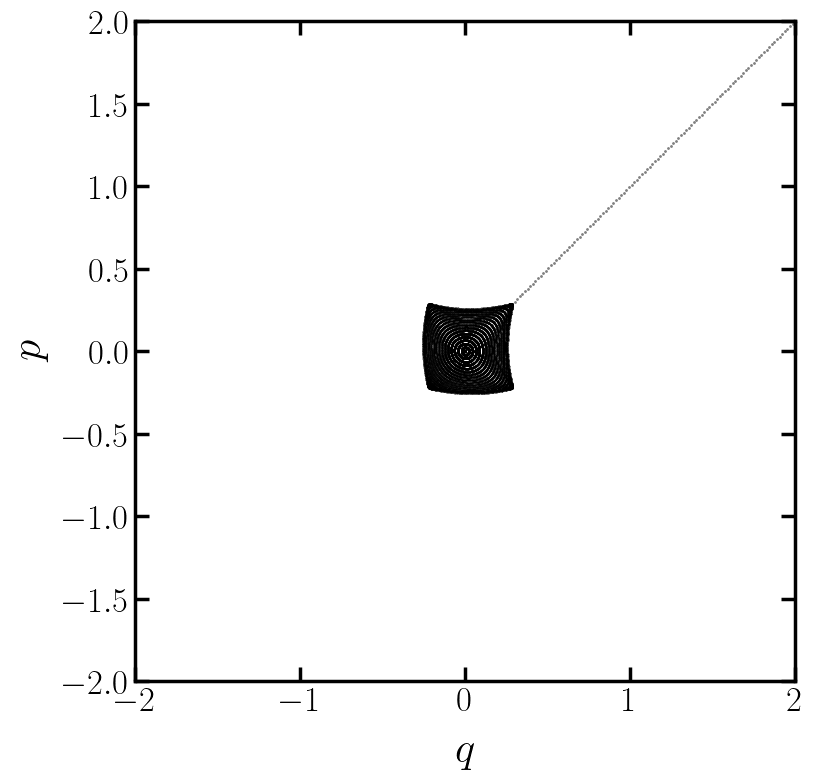

In [23]:
# Plot non-escaping phase space trajectories (inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.scatter(*xs.T, s=1, marker="o", c="grey", alpha=1.0, zorder=0)
ax.scatter(*os_a_inverse.reshape(-1, 1 + 1).T, s=0.1, marker="o", c="black", alpha=0.75, zorder=1)
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25*fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25*fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75*tick_width, length=0.75*tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

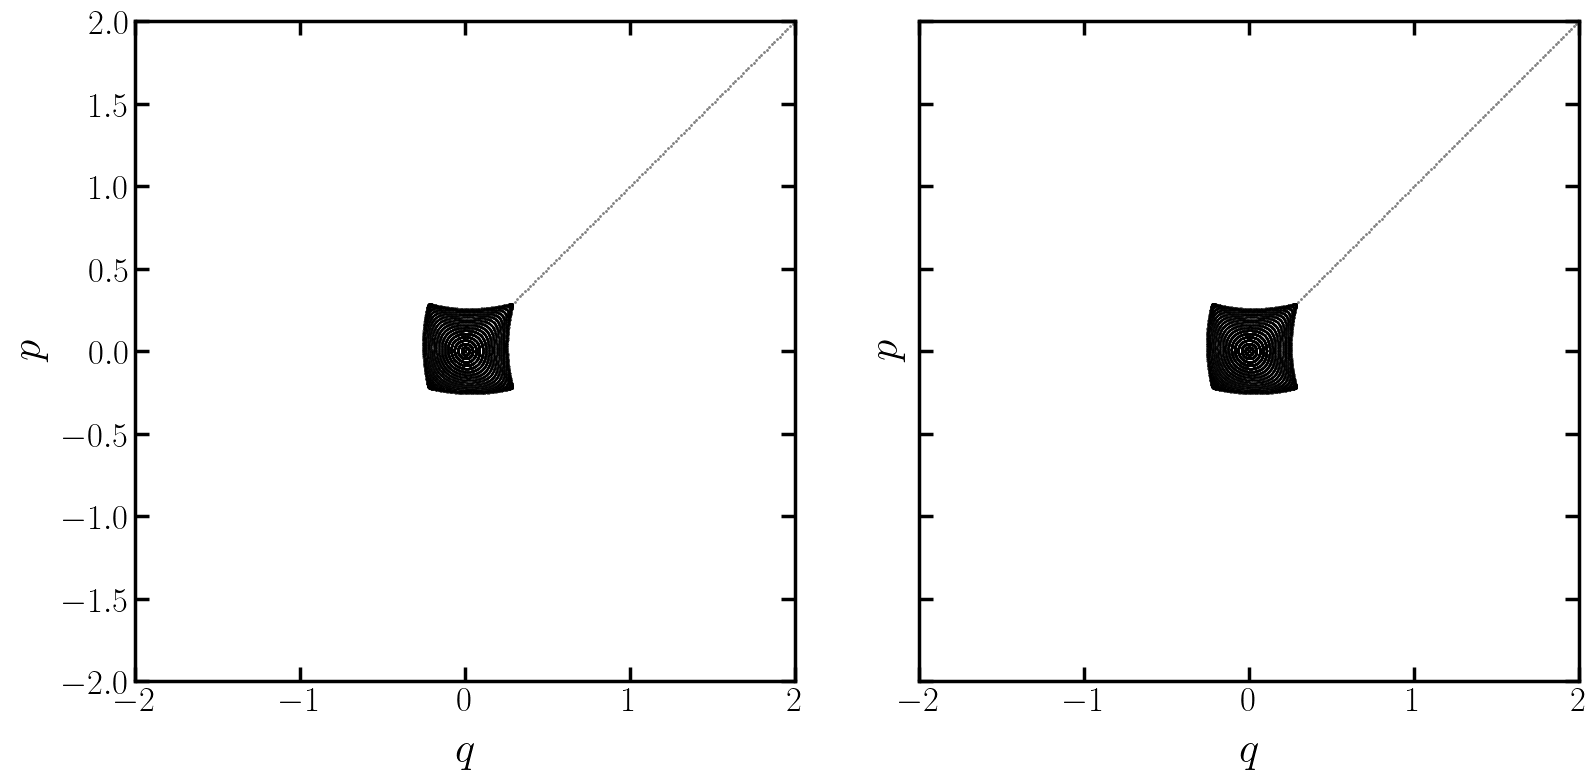

In [24]:
# Plot non-escaping phase space trajectories (forward vs inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, (ax, ay) = plt.subplots(1, 2, figsize=(16.0, 8.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.080, right=0.985, bottom=0.150, top=0.975, wspace=0.18)

ax.scatter(*xs.T, s=1, marker="o", c="grey", alpha=1.0, zorder=0)
ax.scatter(*os_a.reshape(-1, 2).T, s=0.1, marker="o", c="black", alpha=0.75, zorder=1)
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)

ay.scatter(*xs.T, s=1, marker="o", c="grey", alpha=1.0, zorder=0)
ay.scatter(*os_a_inverse.reshape(-1, 2).T, s=0.1, marker="o", c="black", alpha=0.75, zorder=1)
ay.set_xlim(-2.0, 2.0)
ay.set_ylim(-2.0, 2.0)
ay.set_aspect("equal", adjustable="box")
ay.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ay.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ay.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ay.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ay.spines.values():
    spine.set_linewidth(spine_width)

plt.show()

## Escape: Binary survival maps (2D)

In [25]:
# Set grid

m = 1000
qs = np.linspace(-2.0, 2.0, m)
ps = np.linspace(-2.0, 2.0, m)
xs = np.stack(np.meshgrid(qs, ps, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)

In [26]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, forward2d)

In [27]:
# Set map parameters

a, b = 0.4678, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [28]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result, objective, knobs)

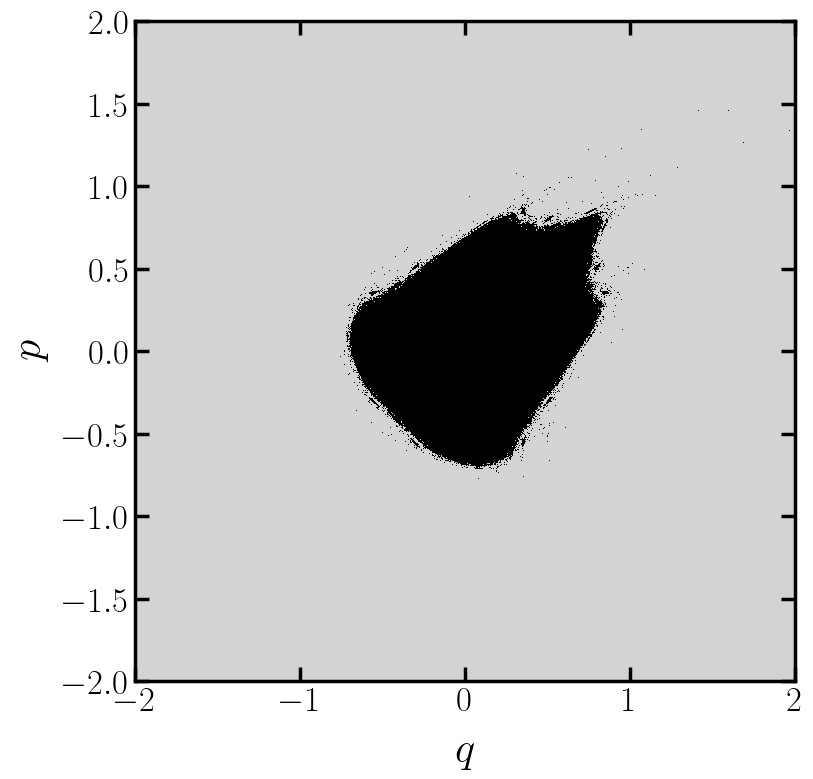

In [29]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

In [30]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, inverse2d)

In [31]:
# Set map parameters

a, b = 0.4678, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [32]:
# Compute survival map

result_inverse = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result_inverse, objective, knobs)

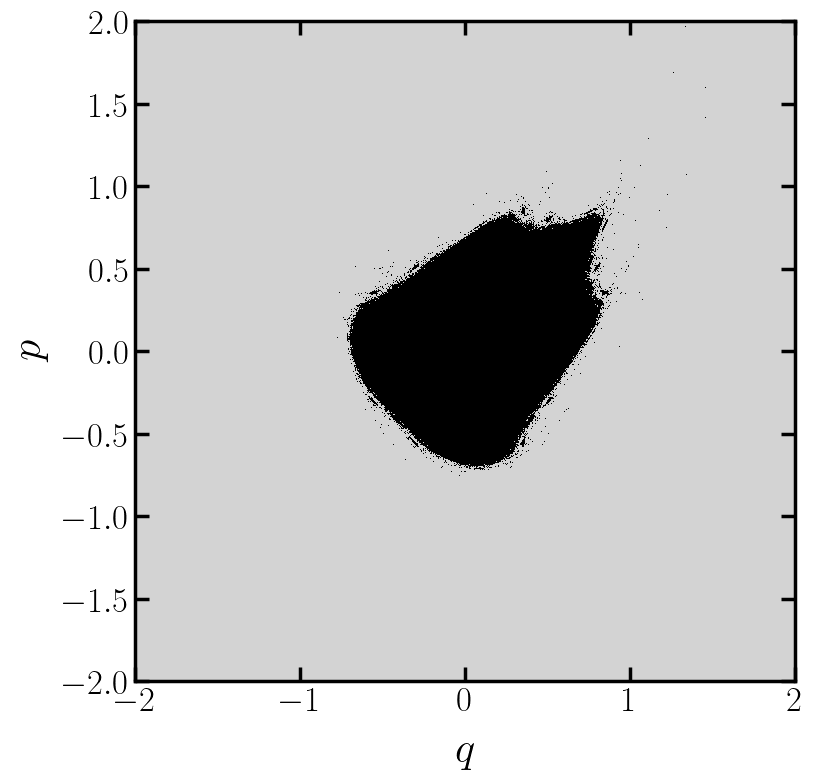

In [33]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result_inverse.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

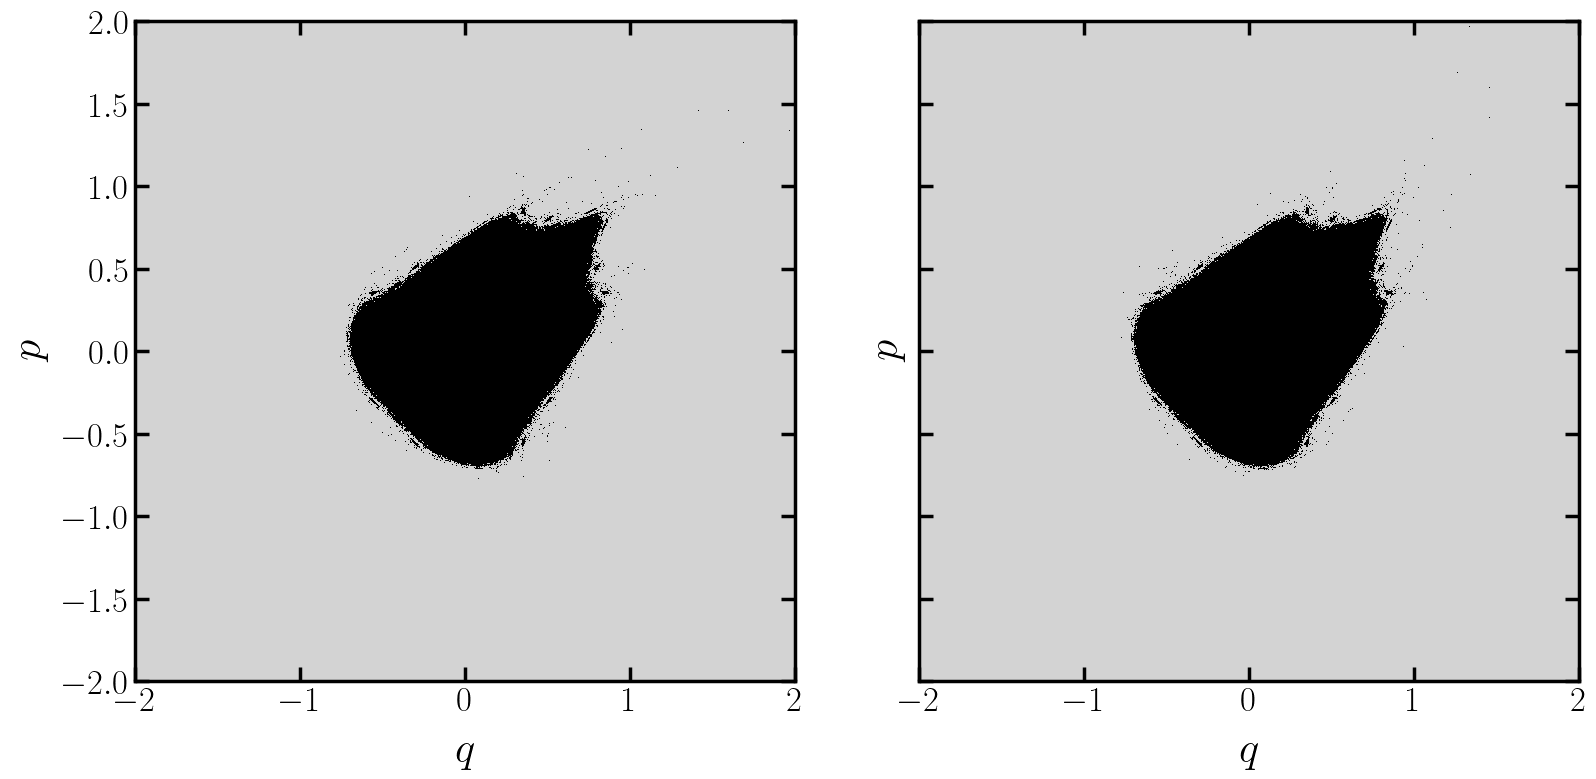

In [34]:
# Plot non-escaping phase space trajectories (forward vs inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, (ax, ay) = plt.subplots(1, 2, figsize=(16.0, 8.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.080, right=0.985, bottom=0.150, top=0.975, wspace=0.18)

ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)

ay.imshow(result_inverse.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ay.set_xlim(-2.0, 2.0)
ay.set_ylim(-2.0, 2.0)
ay.set_aspect("equal", adjustable="box")
ay.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ay.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ay.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ay.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ay.spines.values():
    spine.set_linewidth(spine_width)

plt.show()

## Escape: Binary survival maps (4D)

In [35]:
# Set grid

m = 1000
qx = np.linspace(-2, 2, m)
qy = np.linspace(-2, 2, m)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

In [36]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, forward4d)

In [37]:
# Set map parameters

nux, nuy = 0.280, 0.310
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[ 0.  0. -0. -0.]
[-0. -0.  0.  0.]


In [38]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result, objective, knobs)

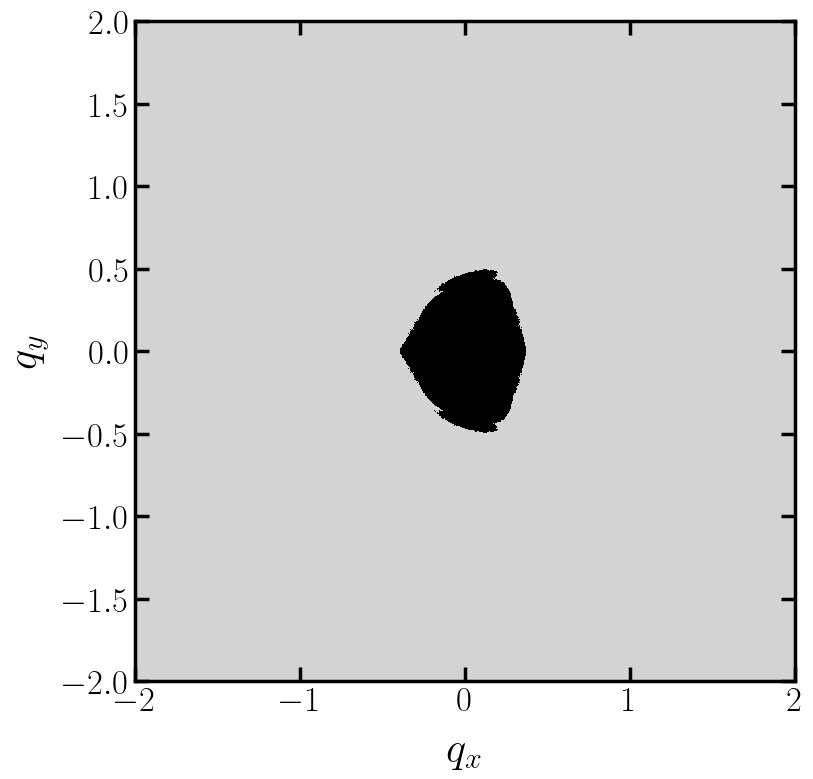

In [39]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

In [40]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, inverse4d)

In [41]:
# Set map parameters

nux, nuy = 0.280, 0.310
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[ 0.  0. -0. -0.]
[-0. -0.  0.  0.]


In [42]:
# Compute survival map

result_inverse = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result_inverse, objective, knobs)

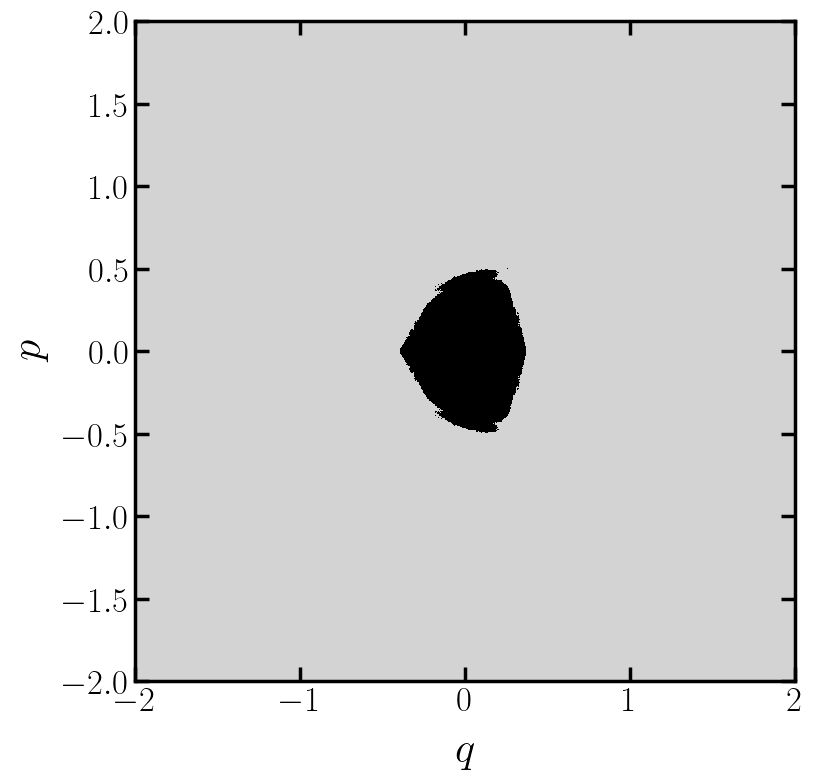

In [43]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result_inverse.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

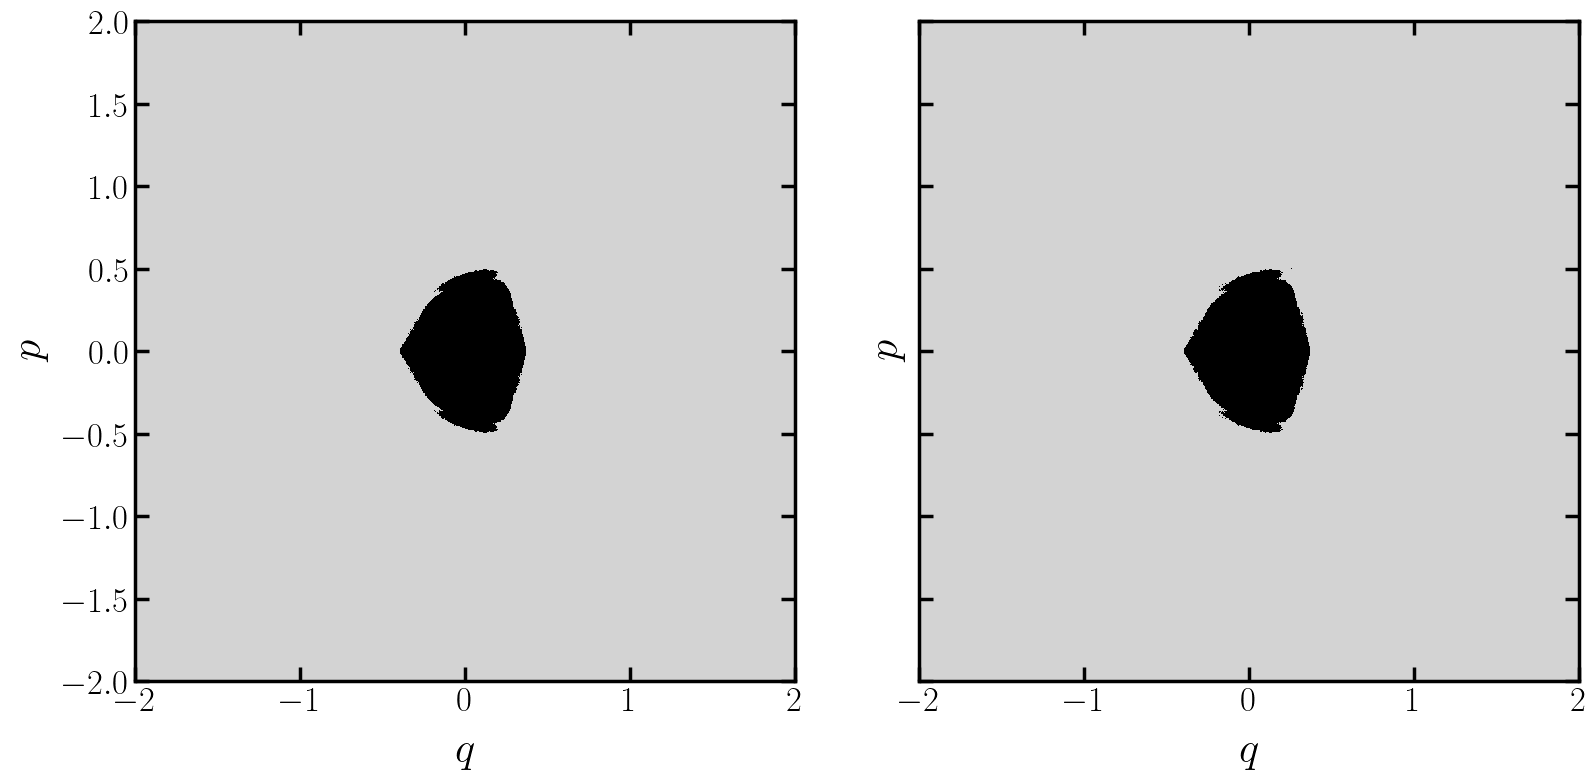

In [44]:
# Plot non-escaping phase space trajectories (forward vs inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, (ax, ay) = plt.subplots(1, 2, figsize=(16.0, 8.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.080, right=0.985, bottom=0.150, top=0.975, wspace=0.18)

ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)

ay.imshow(result_inverse.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ay.set_xlim(-2.0, 2.0)
ay.set_ylim(-2.0, 2.0)
ay.set_aspect("equal", adjustable="box")
ay.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ay.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ay.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ay.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ay.spines.values():
    spine.set_linewidth(spine_width)

plt.show()

## Escape: Binary survival maps (2D & alternative knob values)

In [45]:
# Set grid

m = 1000
qs = np.linspace(-2.0, 2.0, m)
ps = np.linspace(-2.0, 2.0, m)
xs = np.stack(np.meshgrid(qs, ps, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)

In [46]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, forward2d)

In [47]:
# Set map parameters

a, b = -0.065, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [48]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result, objective, knobs)

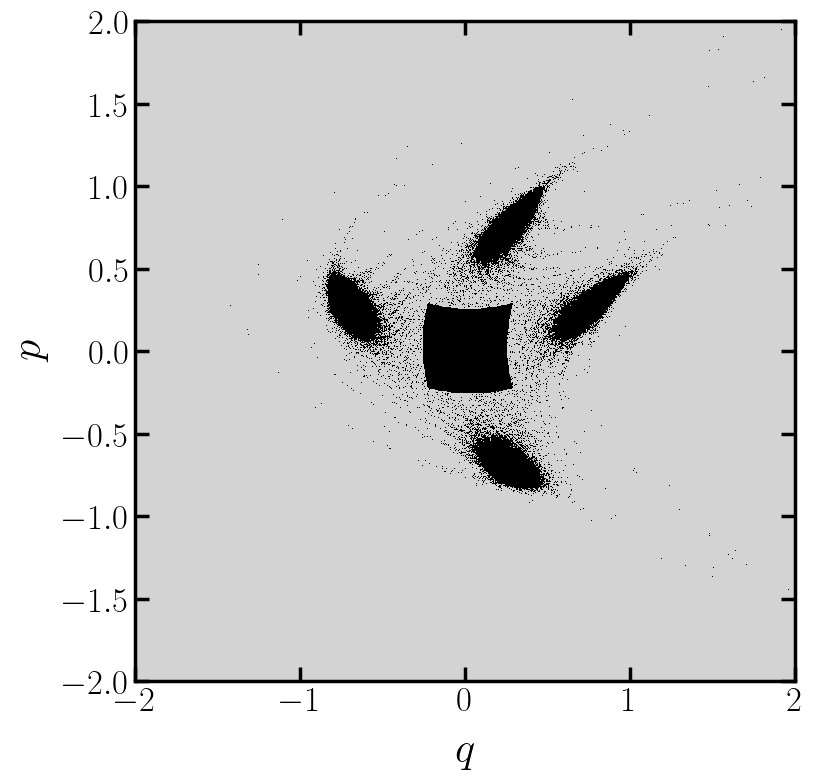

In [49]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

In [50]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, inverse2d)

In [51]:
# Set map parameters

a, b = -0.065, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [52]:
# Compute survival map

result_inverse = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result_inverse, objective, knobs)

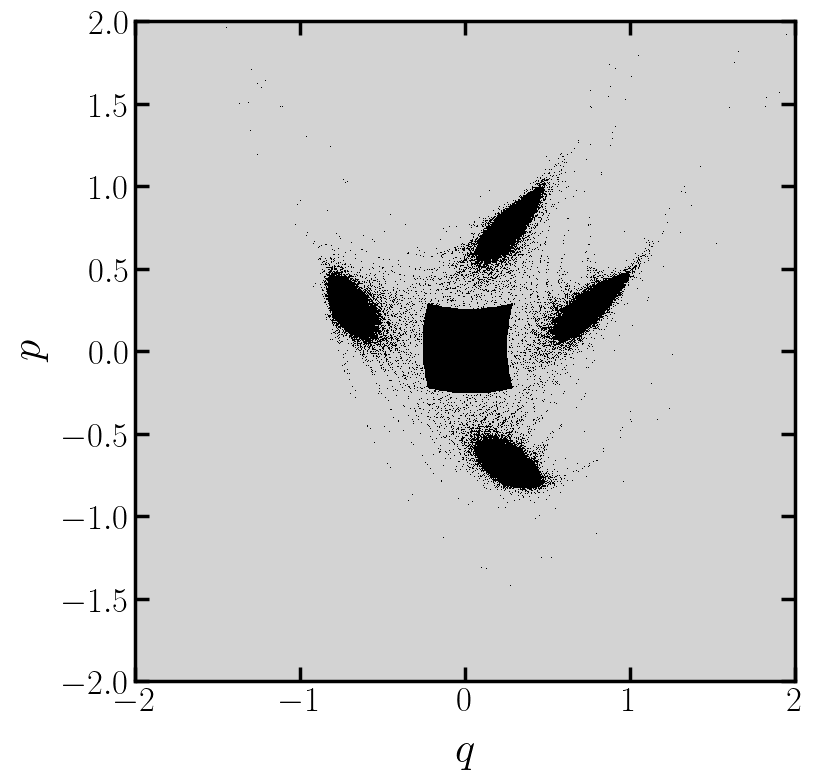

In [53]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result_inverse.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

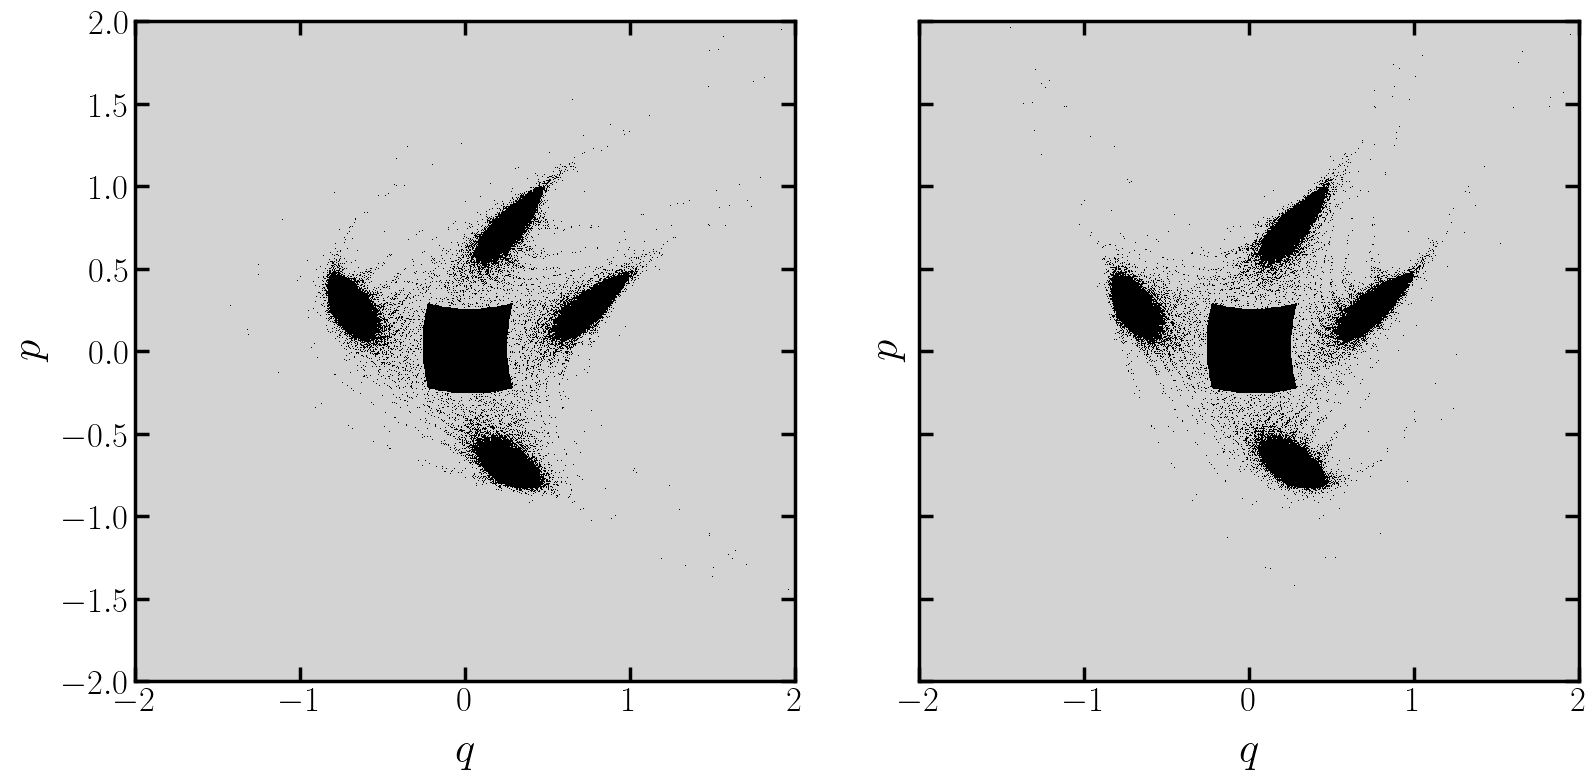

In [54]:
# Plot non-escaping phase space trajectories (forward vs inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, (ax, ay) = plt.subplots(1, 2, figsize=(16.0, 8.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.080, right=0.985, bottom=0.150, top=0.975, wspace=0.18)

ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)

ay.imshow(result_inverse.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ay.set_xlim(-2.0, 2.0)
ay.set_ylim(-2.0, 2.0)
ay.set_aspect("equal", adjustable="box")
ay.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ay.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ay.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ay.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ay.spines.values():
    spine.set_linewidth(spine_width)

plt.show()

## Escape: Binary survival maps (4D & alternative knob values)

In [55]:
# Set grid

m = 1000
qx = np.linspace(-2, 2, m)
qy = np.linspace(-2, 2, m)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

In [56]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, forward4d)

In [57]:
# Set map parameters

nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[0. 0. 0. 0.]
[0. 0. 0. 0.]


In [58]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result, objective, knobs)

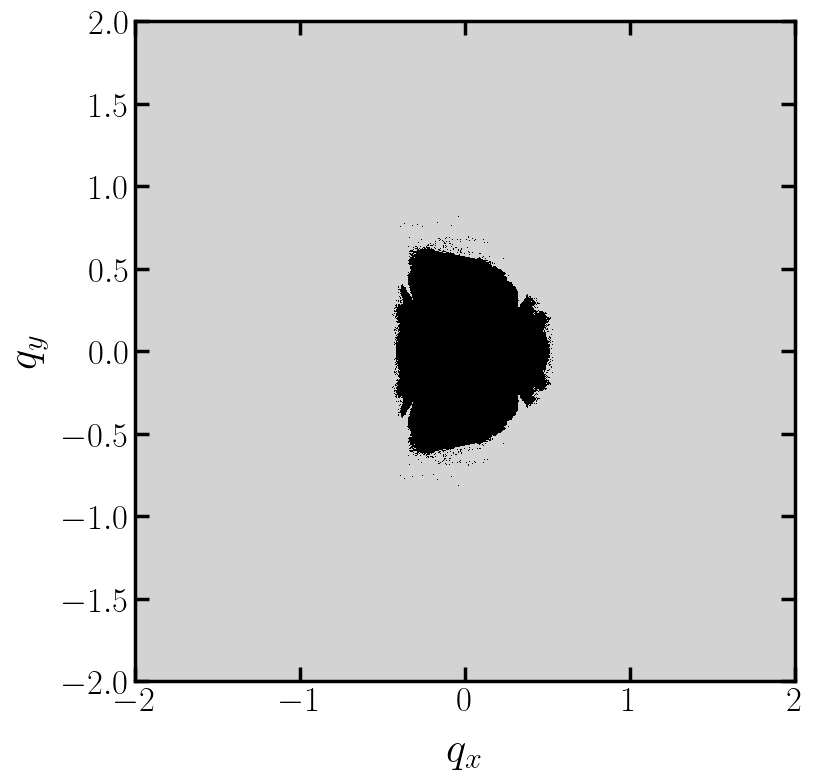

In [59]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

In [60]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, inverse4d)

In [61]:
# Set map parameters

nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[0. 0. 0. 0.]
[0. 0. 0. 0.]


In [62]:
# Compute survival map

result_inverse = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result_inverse, objective, knobs)

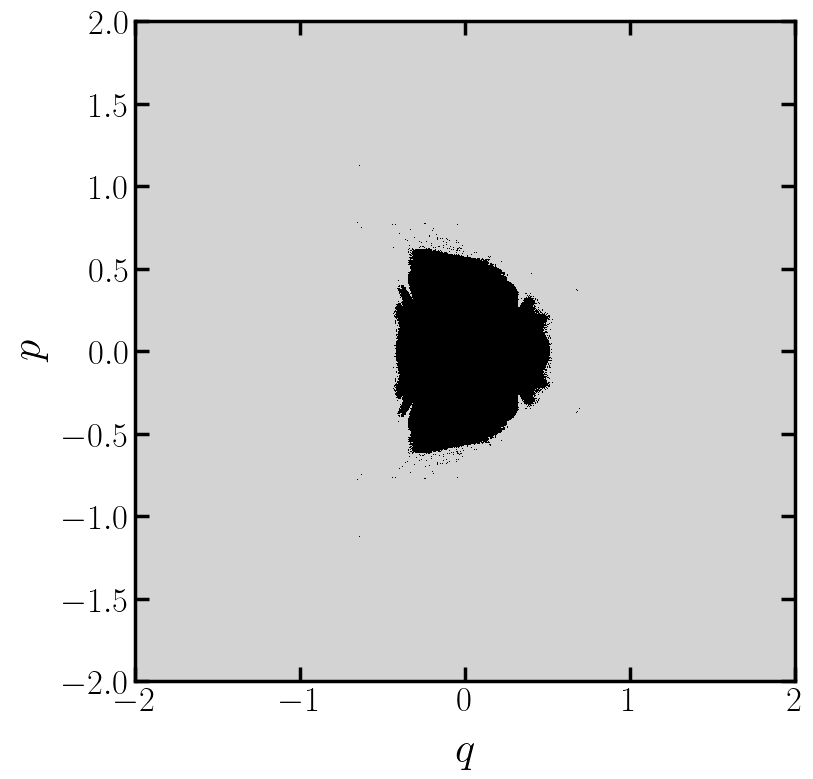

In [63]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result_inverse.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

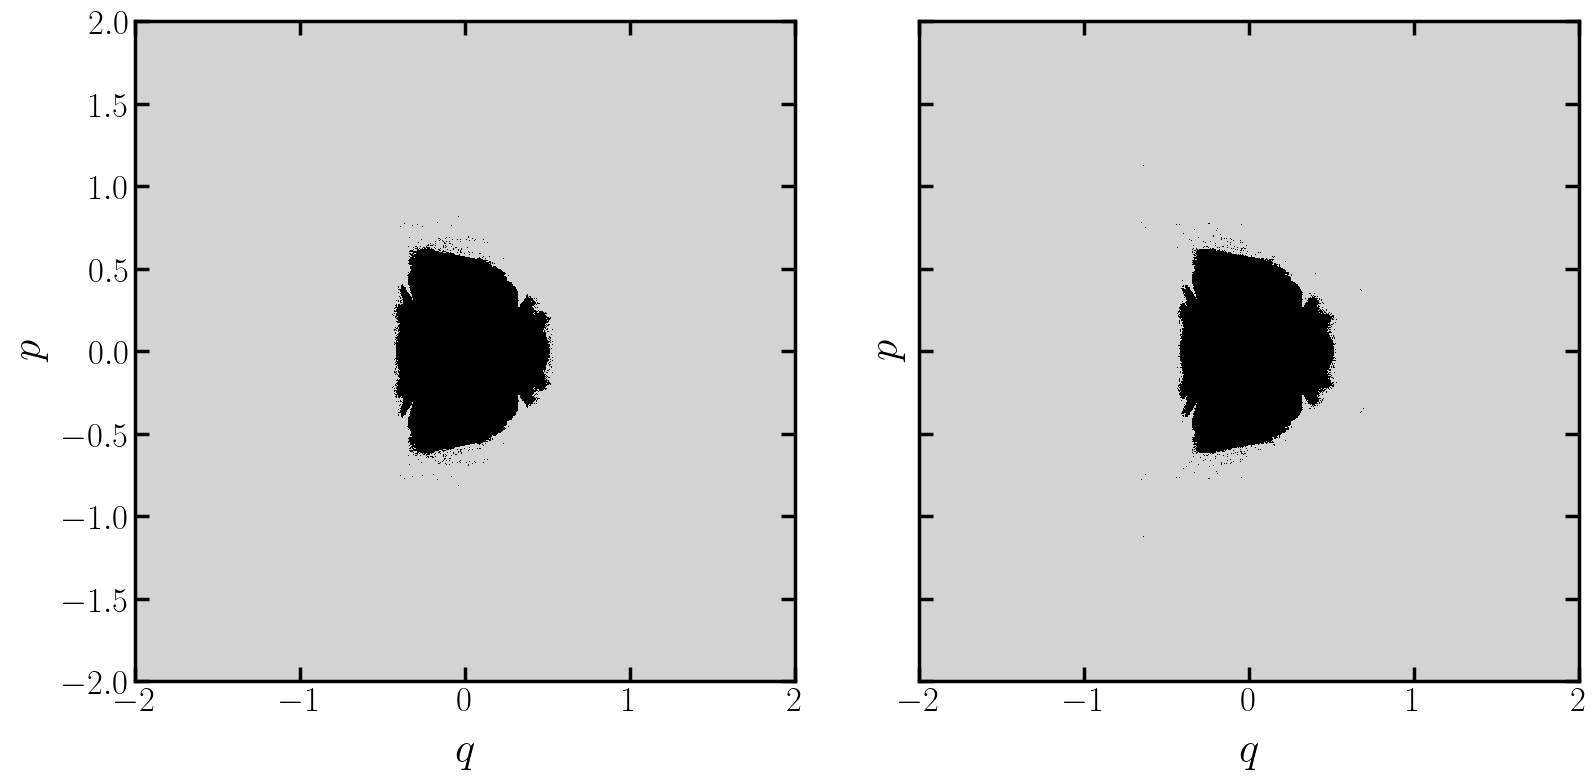

In [64]:
# Plot non-escaping phase space trajectories (forward vs inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, (ax, ay) = plt.subplots(1, 2, figsize=(16.0, 8.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.080, right=0.985, bottom=0.150, top=0.975, wspace=0.18)

ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)

ay.imshow(result_inverse.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ay.set_xlim(-2.0, 2.0)
ay.set_ylim(-2.0, 2.0)
ay.set_aspect("equal", adjustable="box")
ay.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ay.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ay.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ay.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ay.spines.values():
    spine.set_linewidth(spine_width)

plt.show()

## Escape: Small vs large number of iterations (2D)

In [65]:
# Set grid

m = 1000
qs = np.linspace(-2.0, 2.0, m)
ps = np.linspace(-2.0, 2.0, m)
xs = np.stack(np.meshgrid(qs, ps, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)

In [66]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, forward2d)

In [67]:
# Set map parameters

a, b = 0.4678, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [68]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result, objective, knobs)

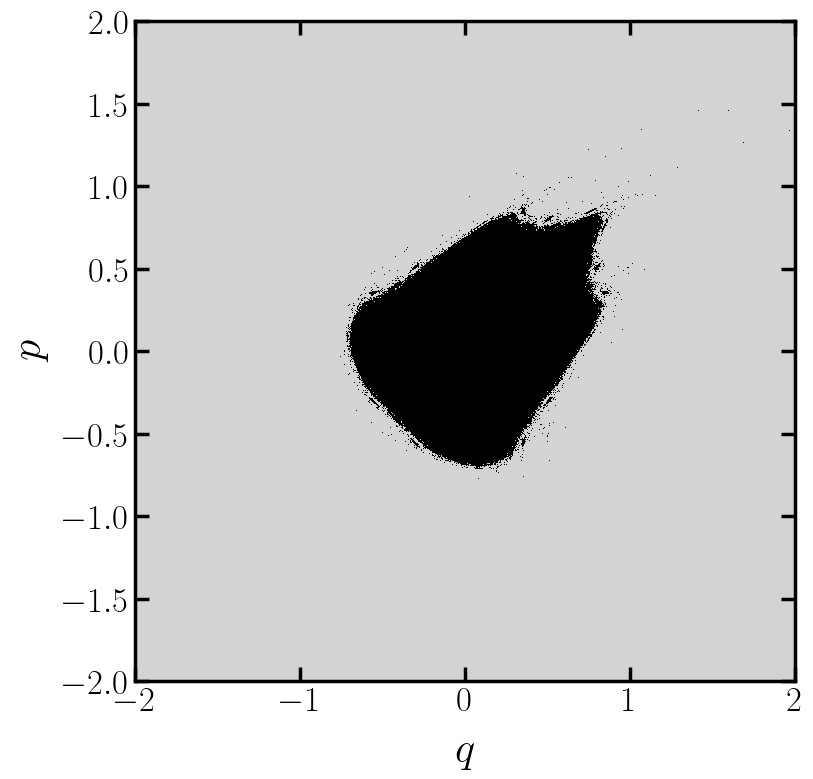

In [69]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

In [70]:
# Set escape objective

n = 2**20
r = 100.0
objective = iterate(n, r, forward2d)

In [71]:
# Set map parameters

a, b = 0.4678, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [72]:
# Compute survival map

result_long = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result_long, objective, knobs)

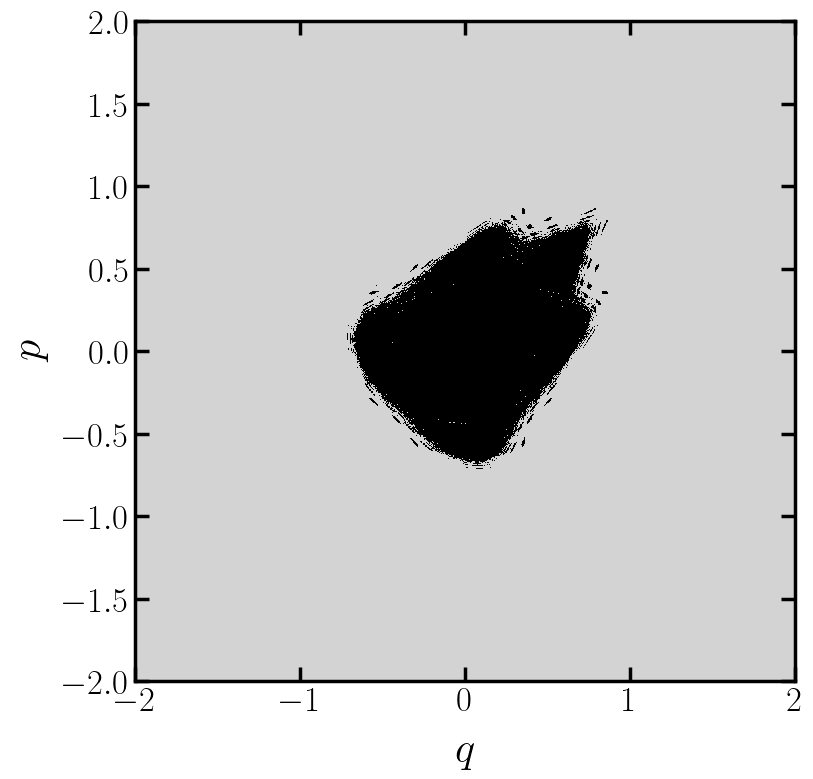

In [73]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result_long.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

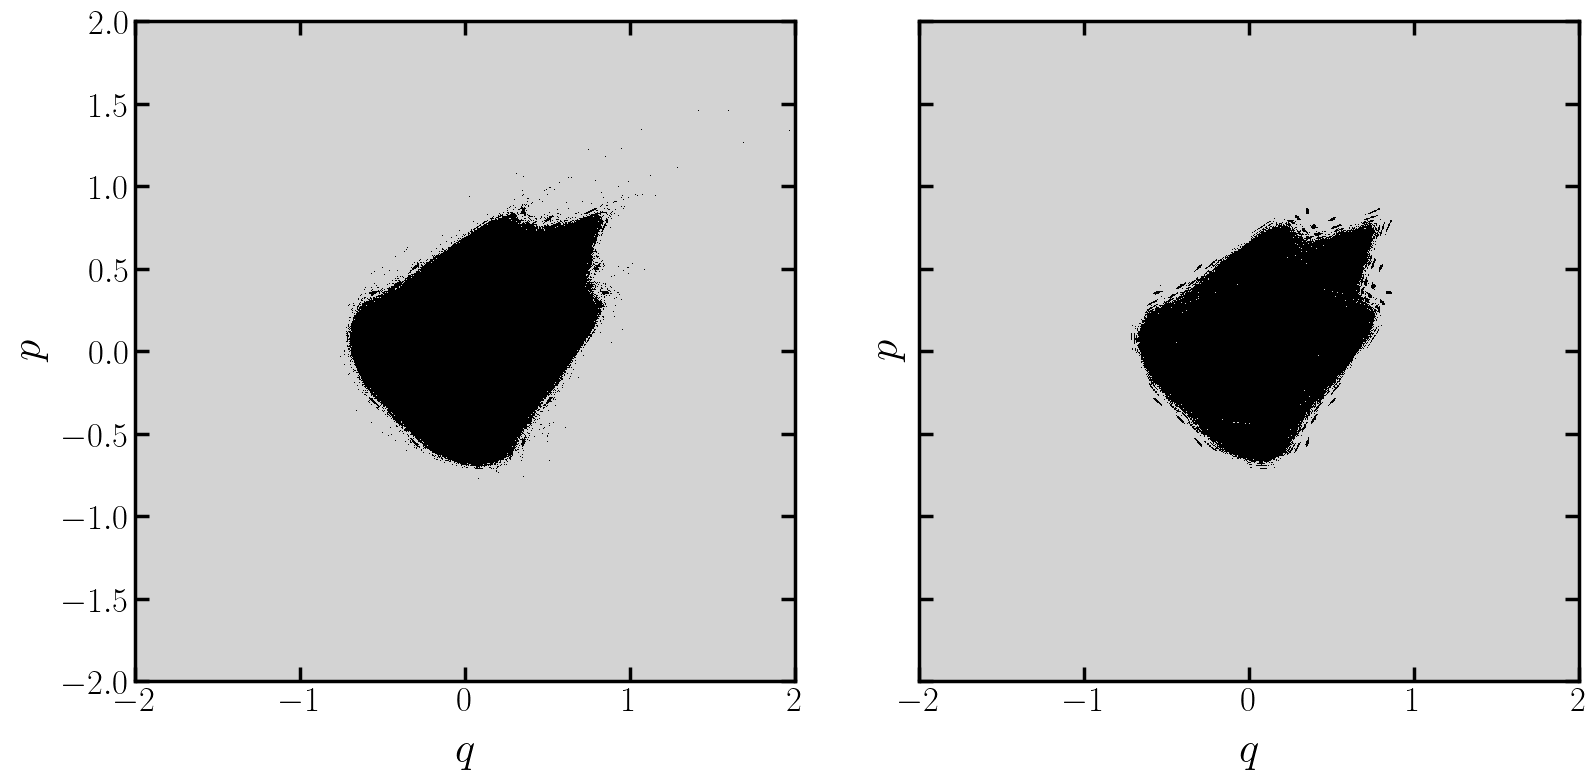

In [74]:
# Plot non-escaping phase space trajectories (short vs long)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, (ax, ay) = plt.subplots(1, 2, figsize=(16.0, 8.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.080, right=0.985, bottom=0.150, top=0.975, wspace=0.18)

ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)

ay.imshow(result_long.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ay.set_xlim(-2.0, 2.0)
ay.set_ylim(-2.0, 2.0)
ay.set_aspect("equal", adjustable="box")
ay.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ay.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ay.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ay.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ay.spines.values():
    spine.set_linewidth(spine_width)

plt.show()

## Escape: Small vs large number of iterations (4D)

In [75]:
# Set grid

m = 1000
qx = np.linspace(-2, 2, m)
qy = np.linspace(-2, 2, m)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

In [76]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, forward4d)

In [77]:
# Set map parameters

nux, nuy = 0.280, 0.310
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[ 0.  0. -0. -0.]
[-0. -0.  0.  0.]


In [78]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result, objective, knobs)

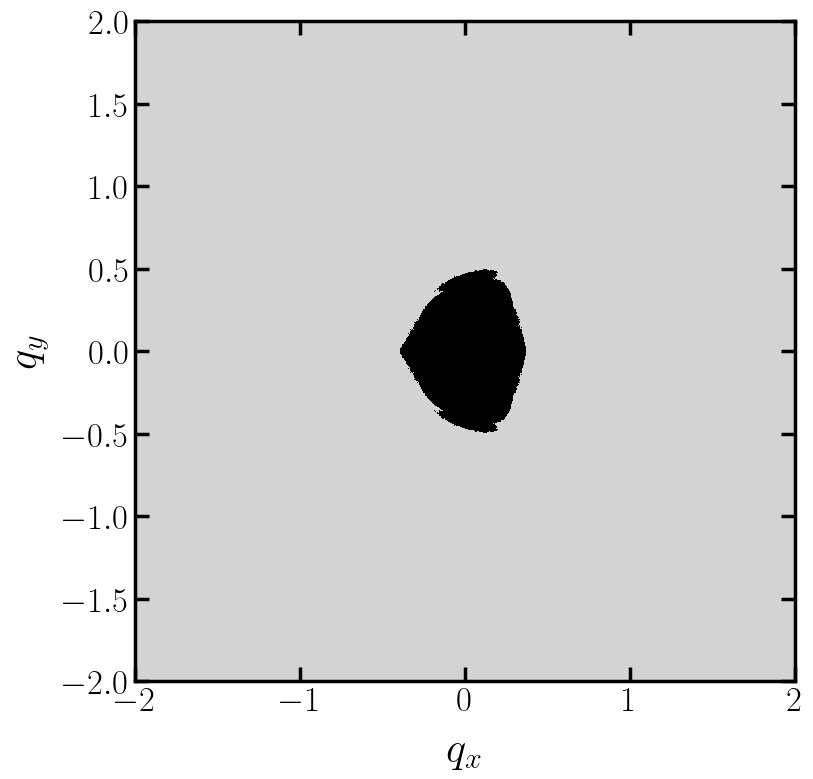

In [79]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

In [80]:
# Set grid

m = 1000
qx = np.linspace(-2, 2, m)
qy = np.linspace(-2, 2, m)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

In [81]:
# Set escape objective

n = 2**20
r = 100.0
objective = iterate(n, r, forward4d)

In [82]:
# Set map parameters

nux, nuy = 0.280, 0.310
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[ 0.  0. -0. -0.]
[-0. -0.  0.  0.]


In [83]:
# Compute survival map

result_long = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result_long, objective, knobs)

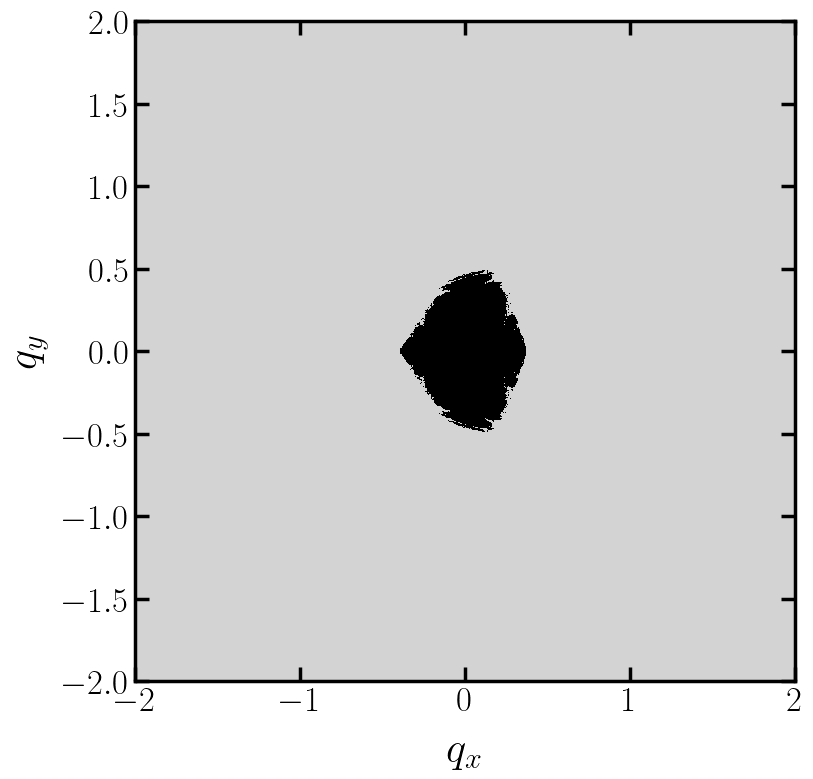

In [84]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result_long.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

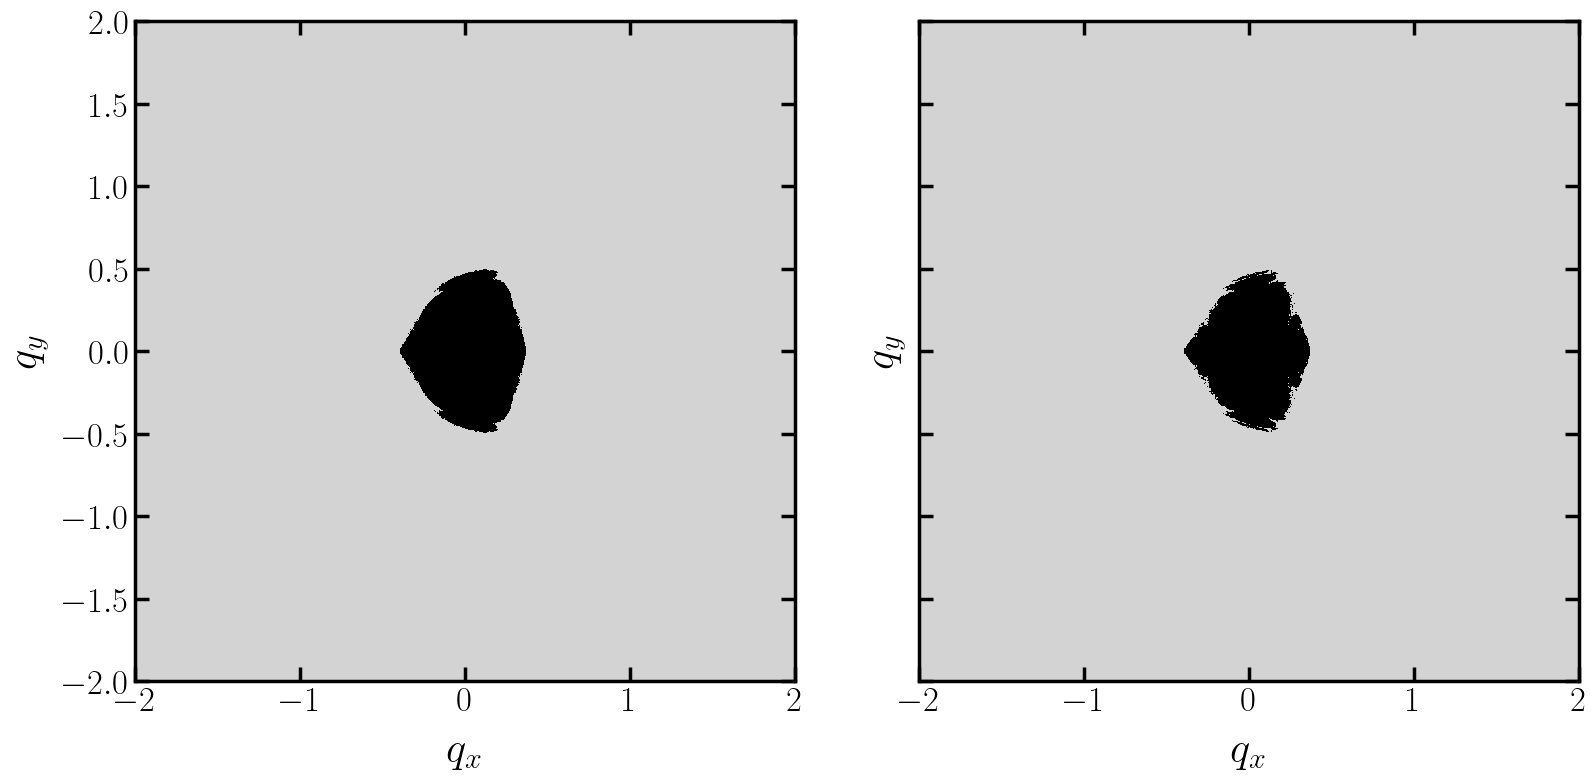

In [85]:
# Plot non-escaping phase space trajectories (short vs long)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, (ax, ay) = plt.subplots(1, 2, figsize=(16.0, 8.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.080, right=0.985, bottom=0.150, top=0.975, wspace=0.18)

ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)

ay.imshow(result_long.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ay.set_xlim(-2.0, 2.0)
ay.set_ylim(-2.0, 2.0)
ay.set_aspect("equal", adjustable="box")
ay.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ay.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ay.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ay.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ay.spines.values():
    spine.set_linewidth(spine_width)

plt.show()

## Escape: Small vs large number of iterations (2D & alternative knob values)

In [86]:
# Set grid

m = 1000
qs = np.linspace(-2.0, 2.0, m)
ps = np.linspace(-2.0, 2.0, m)
xs = np.stack(np.meshgrid(qs, ps, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)

In [87]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, forward2d)

In [88]:
# Set map parameters

a, b = -0.065, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [89]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result, objective, knobs)

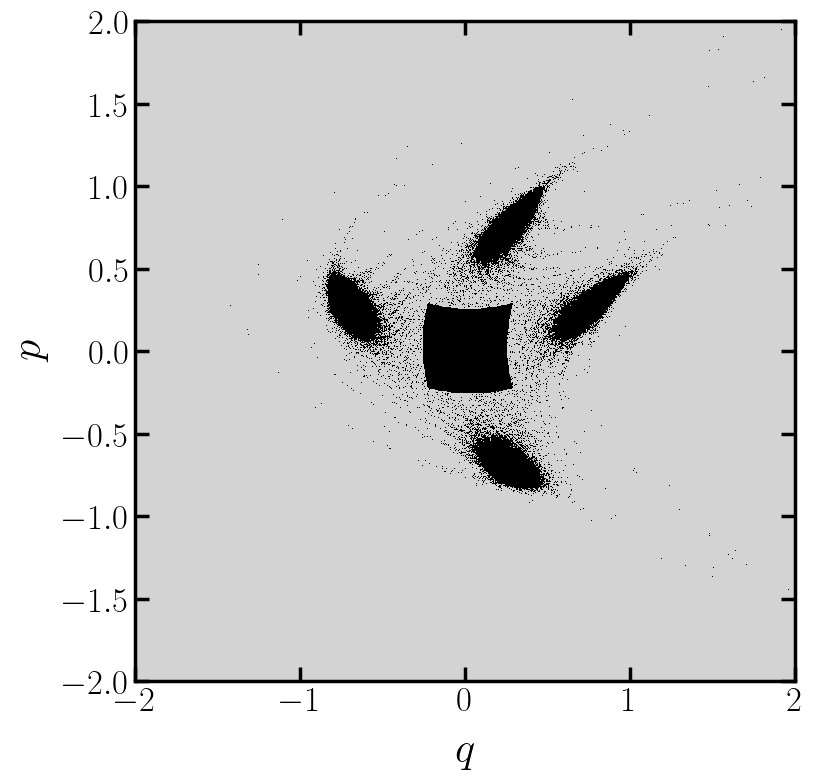

In [90]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

In [91]:
# Set escape objective

n = 2**20
r = 100.0
objective = iterate(n, r, forward2d)

In [92]:
# Set map parameters

a, b = -0.065, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [93]:
# Compute survival map

result_long = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result_long, objective, knobs)

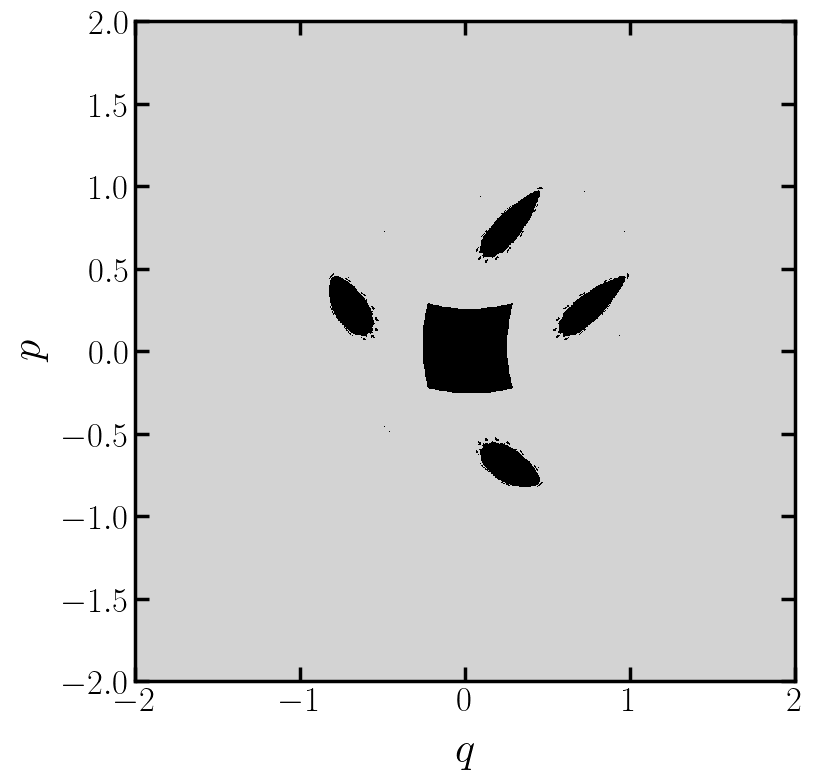

In [94]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result_long.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

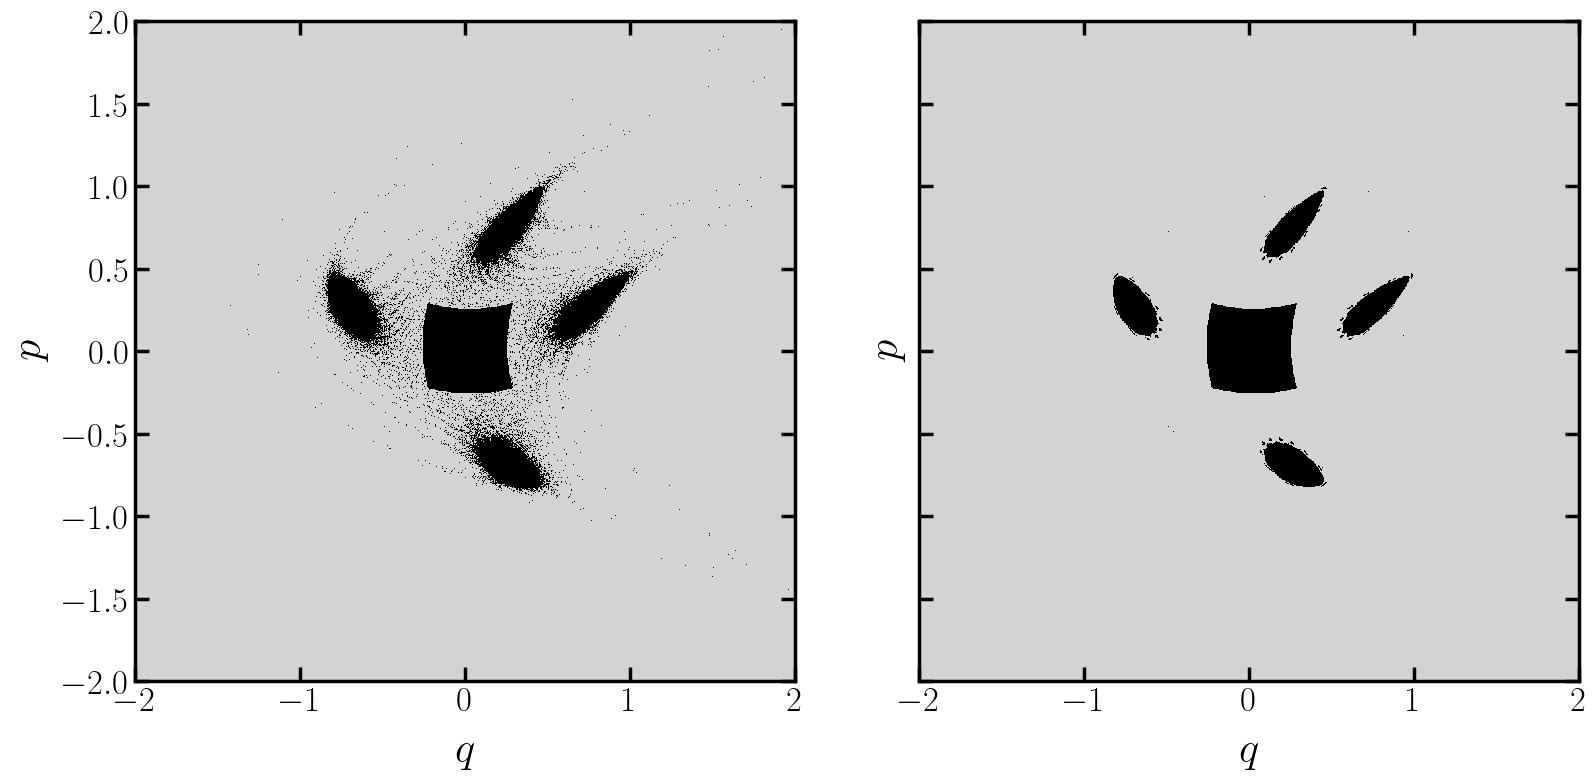

In [95]:
# Plot non-escaping phase space trajectories (forward vs inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, (ax, ay) = plt.subplots(1, 2, figsize=(16.0, 8.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.080, right=0.985, bottom=0.150, top=0.975, wspace=0.18)

ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)

ay.imshow(result_long.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ay.set_xlim(-2.0, 2.0)
ay.set_ylim(-2.0, 2.0)
ay.set_aspect("equal", adjustable="box")
ay.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ay.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ay.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ay.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ay.spines.values():
    spine.set_linewidth(spine_width)

plt.show()

## Escape: Small vs large number of iterations (4D & alternative knob values)

In [96]:
# Set grid

m = 1000
qx = np.linspace(-2, 2, m)
qy = np.linspace(-2, 2, m)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

In [97]:
# Set escape objective

n = 2**10
r = 100.0
objective = iterate(n, r, forward4d)

In [98]:
# Set map parameters

nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[0. 0. 0. 0.]
[0. 0. 0. 0.]


In [99]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result, objective, knobs)

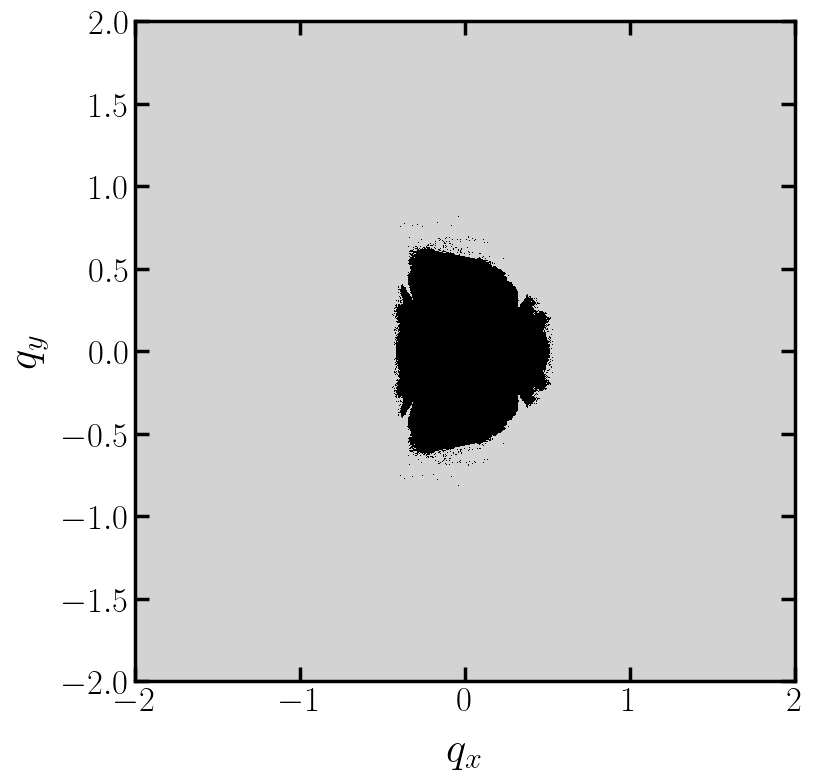

In [100]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

In [101]:
# Set grid

m = 1000
qx = np.linspace(-2, 2, m)
qy = np.linspace(-2, 2, m)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

In [102]:
# Set escape objective

n = 2**20
r = 100.0
objective = iterate(n, r, forward4d)

In [103]:
# Set map parameters

nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[0. 0. 0. 0.]
[0. 0. 0. 0.]


In [104]:
# Compute survival map

result_long = np.zeros((len(xs, )), dtype=np.bool_)
scan(xs, result_long, objective, knobs)

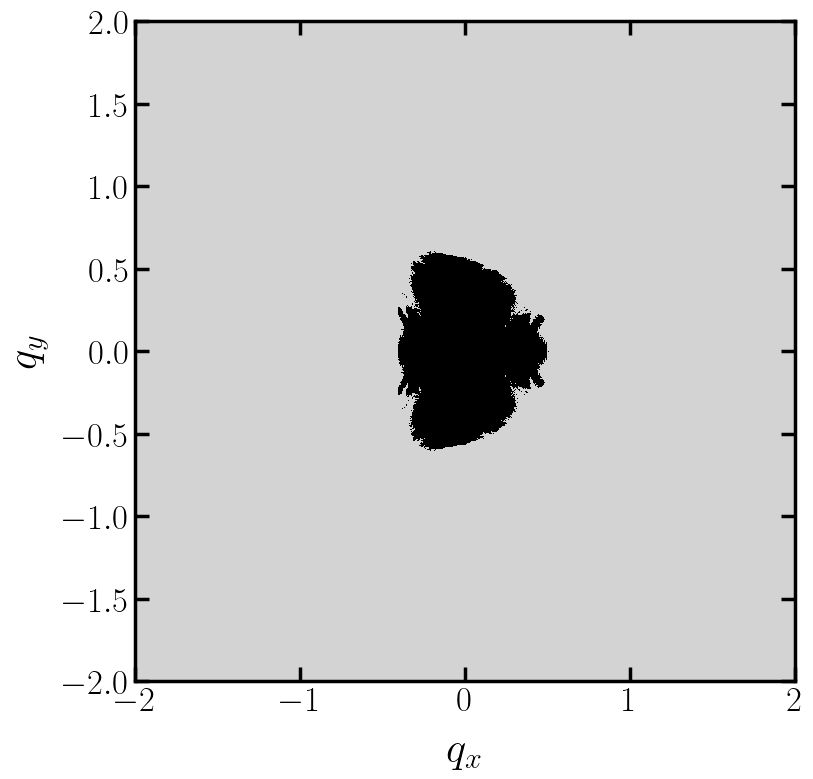

In [105]:
# Plot survival map

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["lightgrey", "black"])

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
ax.imshow(result_long.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
plt.show()

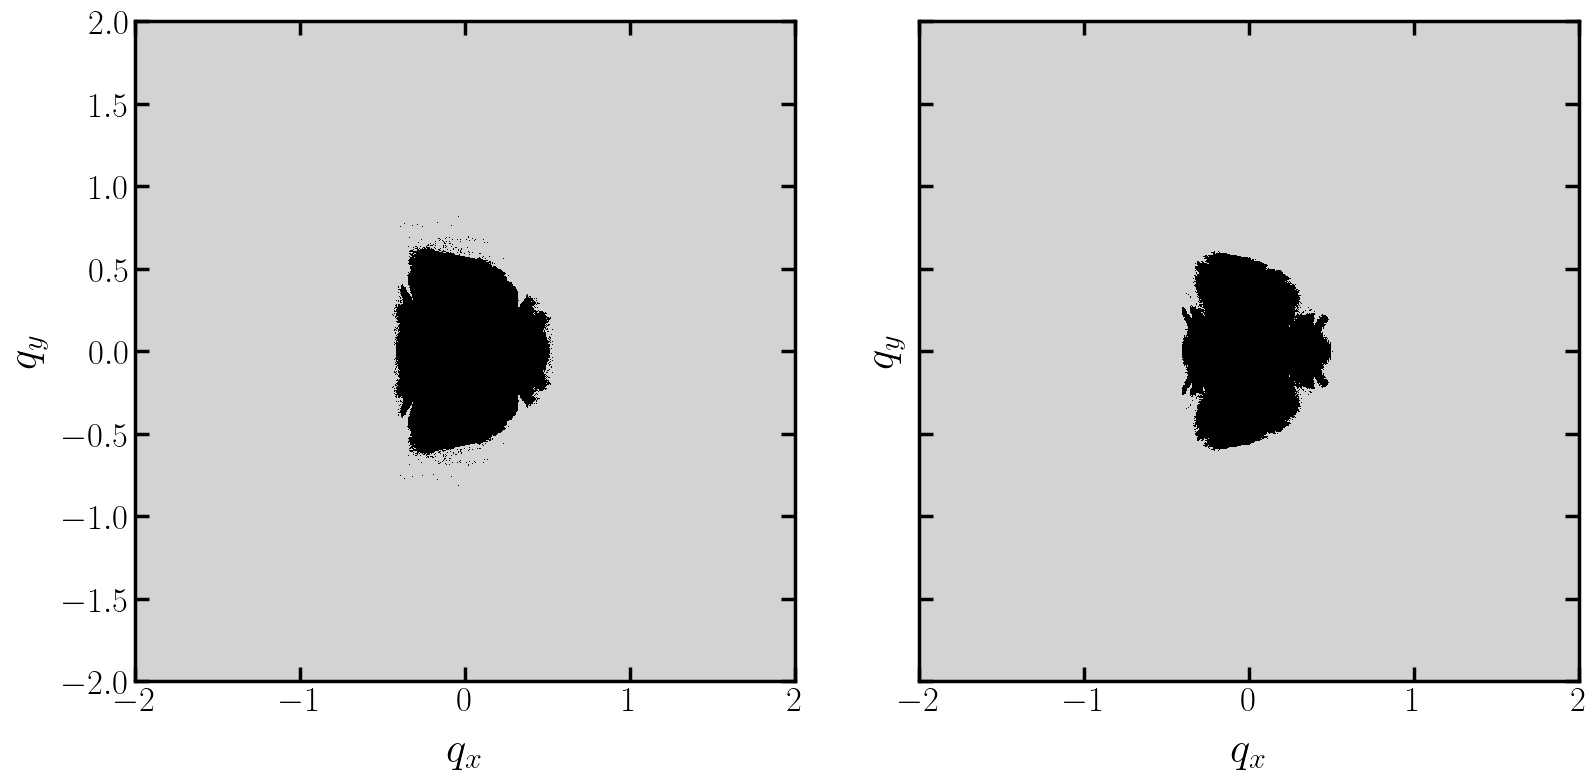

In [106]:
# Plot non-escaping phase space trajectories (short vs long)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

fig, (ax, ay) = plt.subplots(1, 2, figsize=(16.0, 8.0), sharex=True, sharey=True)
fig.subplots_adjust(left=0.080, right=0.985, bottom=0.150, top=0.975, wspace=0.18)

ax.imshow(result.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)

ay.imshow(result_long.reshape(m, m), origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ay.set_xlim(-2.0, 2.0)
ay.set_ylim(-2.0, 2.0)
ay.set_aspect("equal", adjustable="box")
ay.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ay.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ay.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ay.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ay.spines.values():
    spine.set_linewidth(spine_width)

plt.show()

## Escape: Colored survival maps (2D)

In [107]:
# Set grid

m = 1000
qs = np.linspace(-2.0, 2.0, m)
ps = np.linspace(-2.0, 2.0, m)
xs = np.stack(np.meshgrid(qs, ps, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)

In [108]:
# Set escape objective

n = 2**10
r = 100.0
objective = count(n, r, forward2d)

In [109]:
# Set map parameters

a, b = 0.4678, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [110]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, result, objective, knobs)

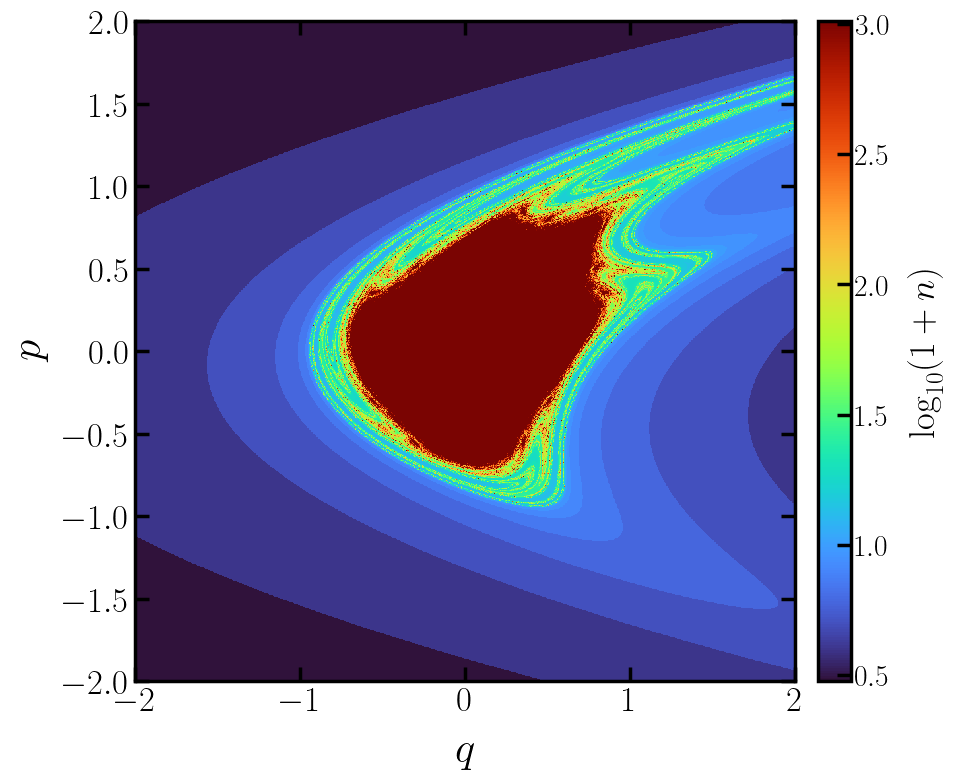

In [111]:
# Plot survival map

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + result.reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

In [112]:
# Set escape objective

n = 2**10
r = 100.0
objective = count(n, r, inverse2d)

In [113]:
# Set map parameters

a, b = 0.4678, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [114]:
# Compute survival map (inverse)

result_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, result_inverse, objective, knobs)

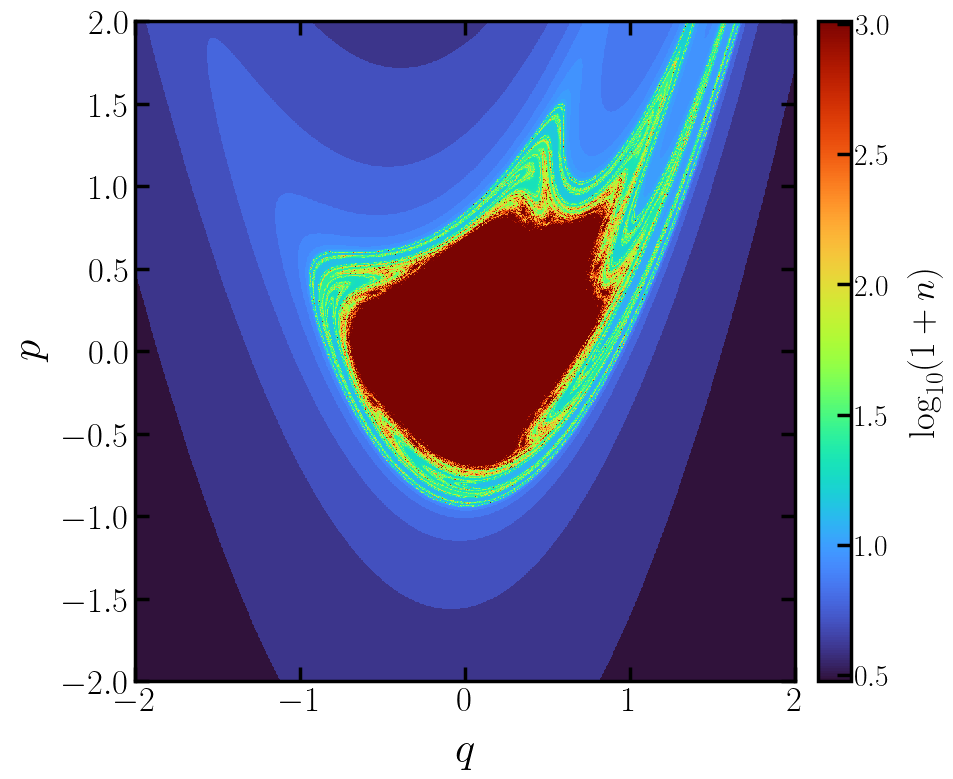

In [115]:
# Plot survival map (inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + result_inverse.reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

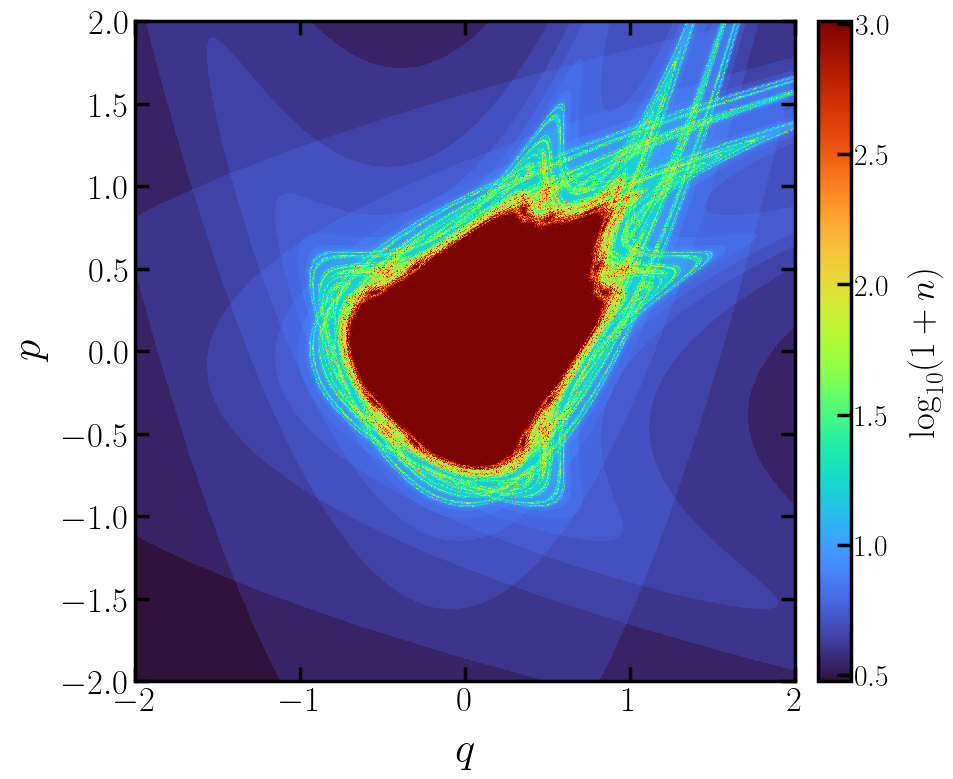

In [116]:
# Plot survival map (combined)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + 1/2*(result + result_inverse).reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

## Escape: Colored survival maps (4D)

In [117]:
# Set grid

m = 1000
qx = np.linspace(-2, 2, m)
qy = np.linspace(-2, 2, m)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

In [118]:
# Set escape objective

n = 2**10
r = 100.0
objective = count(n, r, forward4d)

In [119]:
# Set map parameters

nux, nuy = 0.280, 0.310
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[ 0.  0. -0. -0.]
[-0. -0.  0.  0.]


In [120]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, result, objective, knobs)

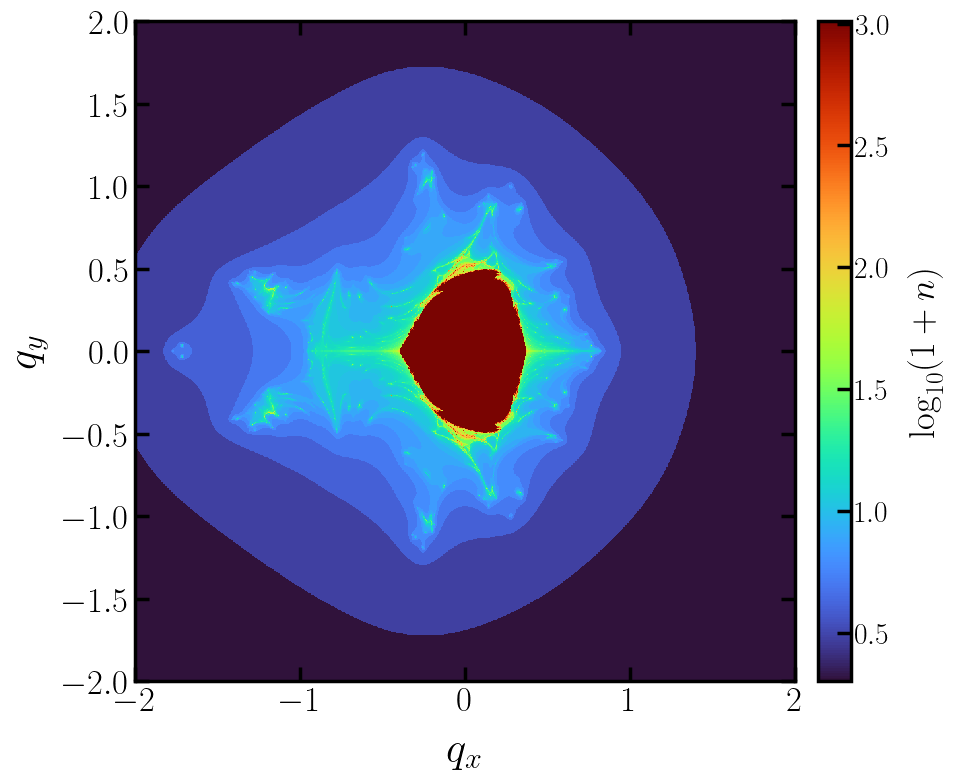

In [121]:
# Plot survival map

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + result.reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

In [122]:
# Set escape objective (inverse)

n = 2**10
r = 100.0
objective = count(n, r, inverse4d)

In [123]:
# Set map parameters

nux, nuy = 0.280, 0.310
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[ 0.  0. -0. -0.]
[-0. -0.  0.  0.]


In [124]:
# Compute survival map (inverse)

result_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, result_inverse, objective, knobs)

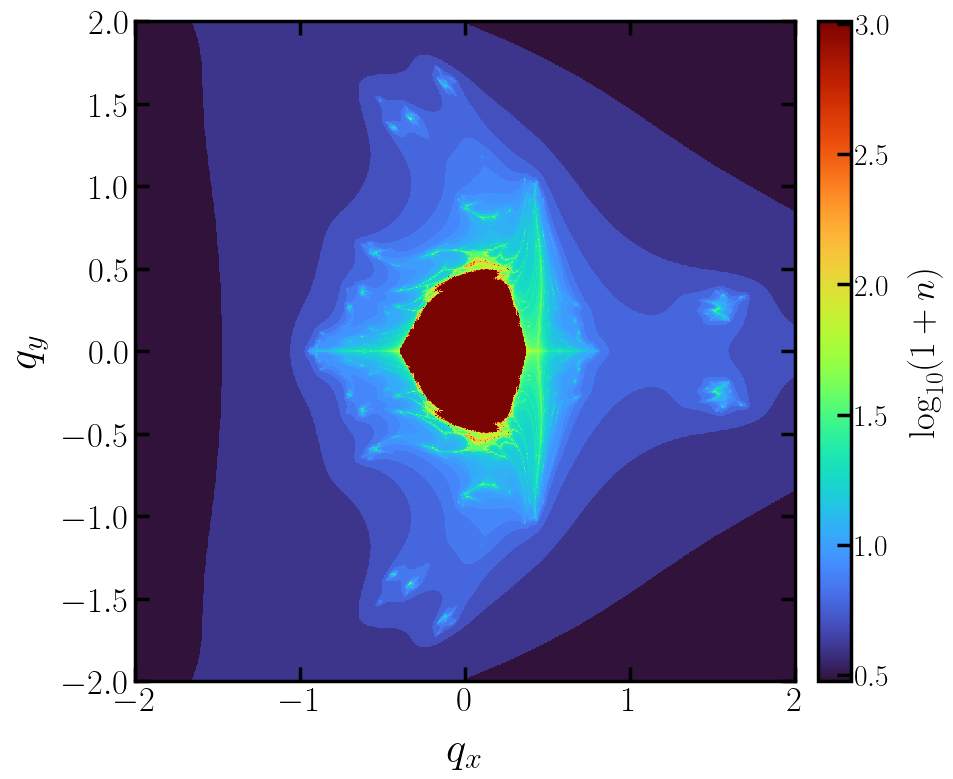

In [125]:
# Plot survival map (inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + result_inverse.reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

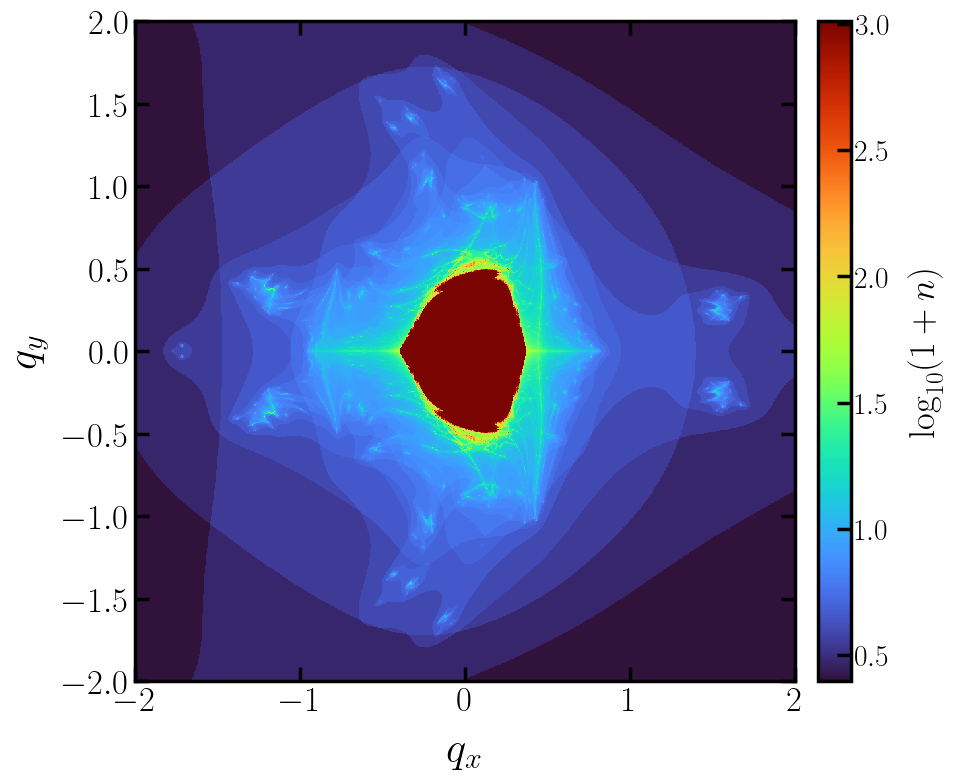

In [126]:
# Plot survival map (combined)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + 1/2*(result + result_inverse).reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

## Escape: Colored survival maps (2D & alternative knob values)

In [127]:
# Set grid

m = 1000
qs = np.linspace(-2.0, 2.0, m)
ps = np.linspace(-2.0, 2.0, m)
xs = np.stack(np.meshgrid(qs, ps, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)

In [128]:
# Set escape objective

n = 2**10
r = 100.0
objective = count(n, r, forward2d)

In [129]:
# Set map parameters

a, b = -0.065, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [130]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, result, objective, knobs)

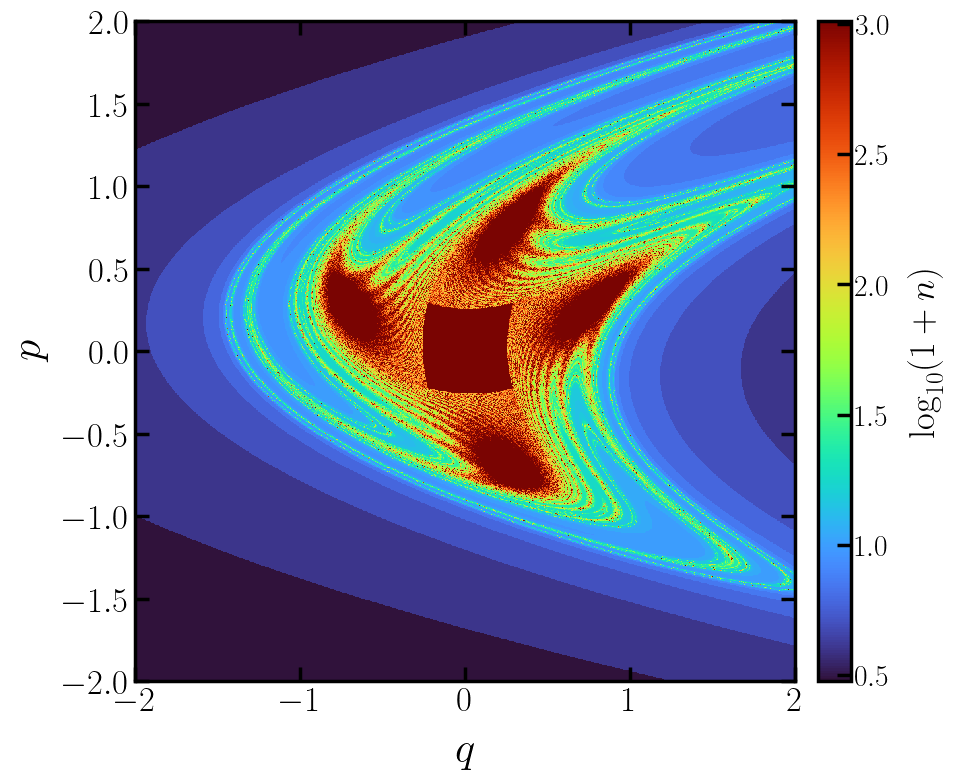

In [131]:
# Plot survival map

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + result.reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

In [132]:
# Set escape objective

n = 2**10
r = 100.0
objective = count(n, r, inverse2d)

In [133]:
# Set map parameters

a, b = -0.065, 0.0
knobs = np.asarray([a, b])
state = np.array([0.0, 0.0])

print(forward2d(state, knobs))
print(inverse2d(state, knobs))

[0. 0.]
[0. 0.]


In [134]:
# Compute survival map (inverse)

result_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, result_inverse, objective, knobs)

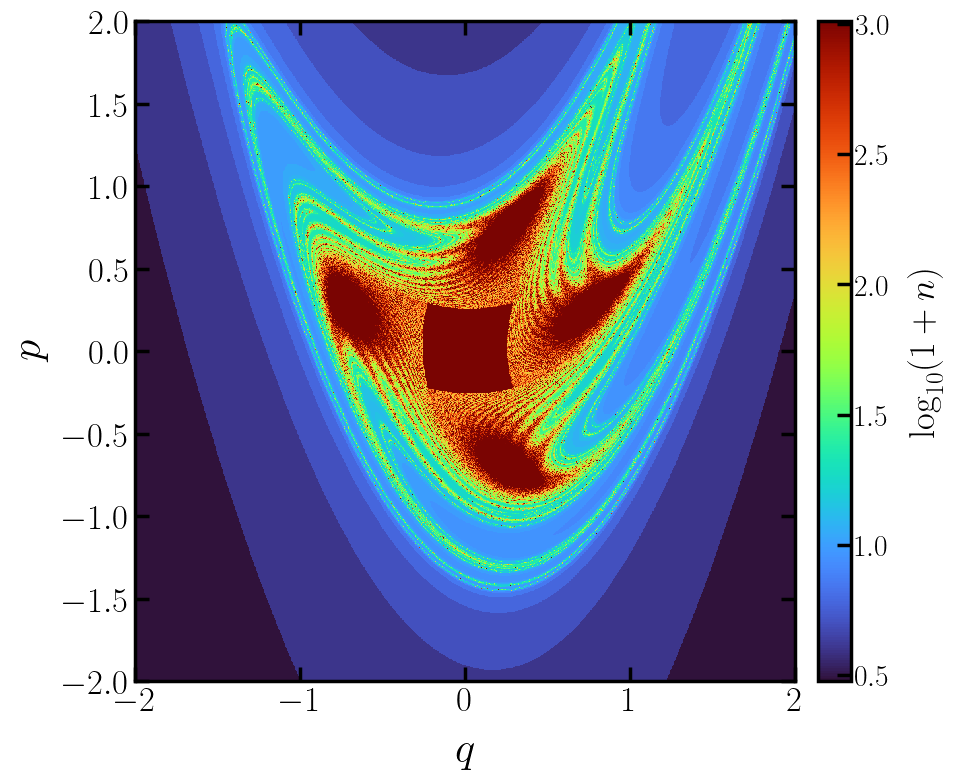

In [135]:
# Plot survival map (inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + result_inverse.reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

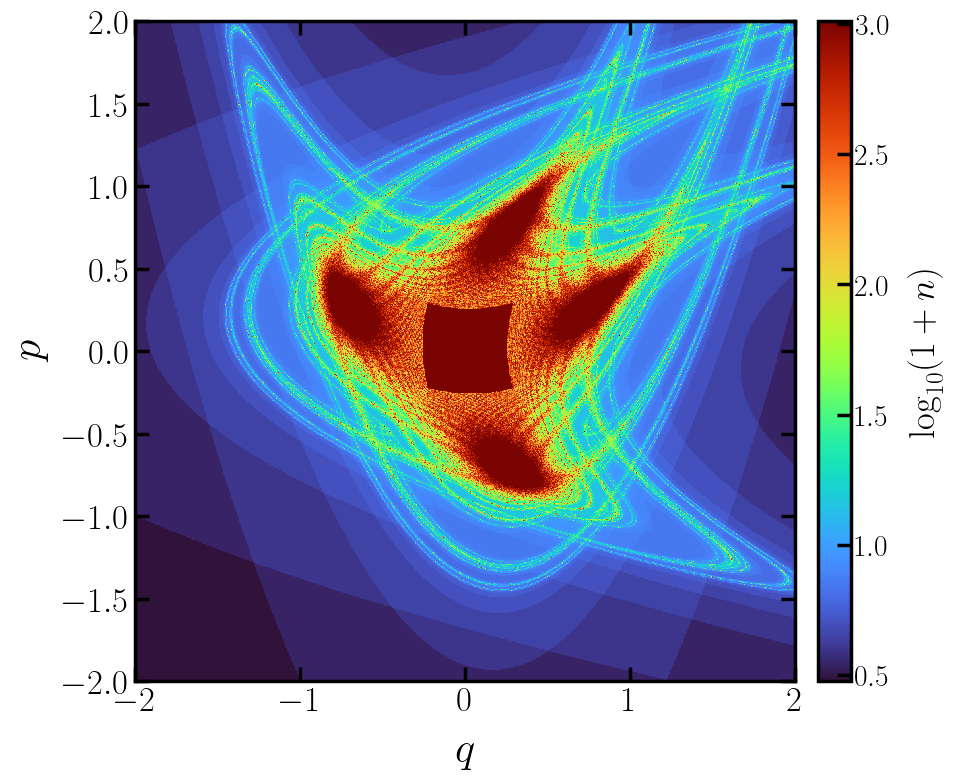

In [136]:
# Plot survival map (combined)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + 1/2*(result + result_inverse).reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$p$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

## Escape: Colored survival maps (4D & alternative knob values)

In [137]:
# Set grid

m = 1000
qx = np.linspace(-2, 2, m)
qy = np.linspace(-2, 2, m)
qxqy = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(m*m, -1)
pxpy = np.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = np.stack([qx, qy, px, py]).T

In [138]:
# Set escape objective

n = 2**10
r = 100.0
objective = count(n, r, forward4d)

In [139]:
# Set map parameters

nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[0. 0. 0. 0.]
[0. 0. 0. 0.]


In [140]:
# Compute survival map

result = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, result, objective, knobs)

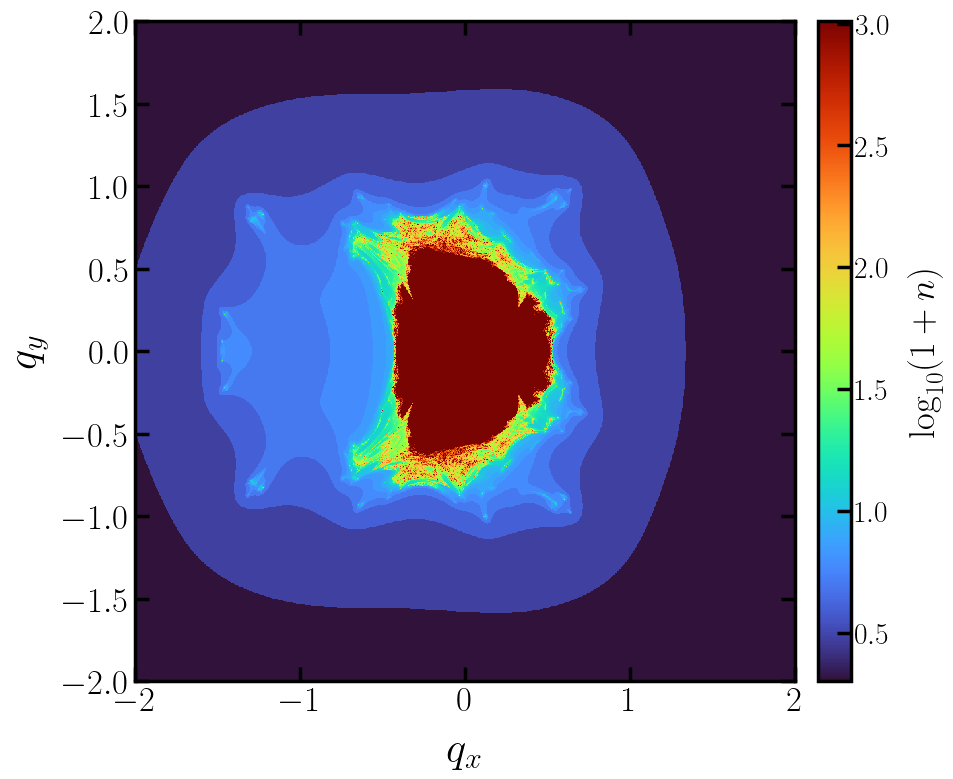

In [141]:
# Plot survival map

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + result.reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

In [142]:
# Set escape objective (inverse)

n = 2**10
r = 100.0
objective = count(n, r, inverse4d)

In [143]:
# Set map parameters

nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 1.0
knobs = np.asarray([cx, sx, cy, sy, mu])
state = np.array([0.0, 0.0, 0.0, 0.0])

print(forward4d(state, knobs))
print(inverse4d(state, knobs))

[0. 0. 0. 0.]
[0. 0. 0. 0.]


In [144]:
# Compute survival map (inverse)

result_inverse = np.zeros((len(xs, )), dtype=np.int64)
scan(xs, result_inverse, objective, knobs)

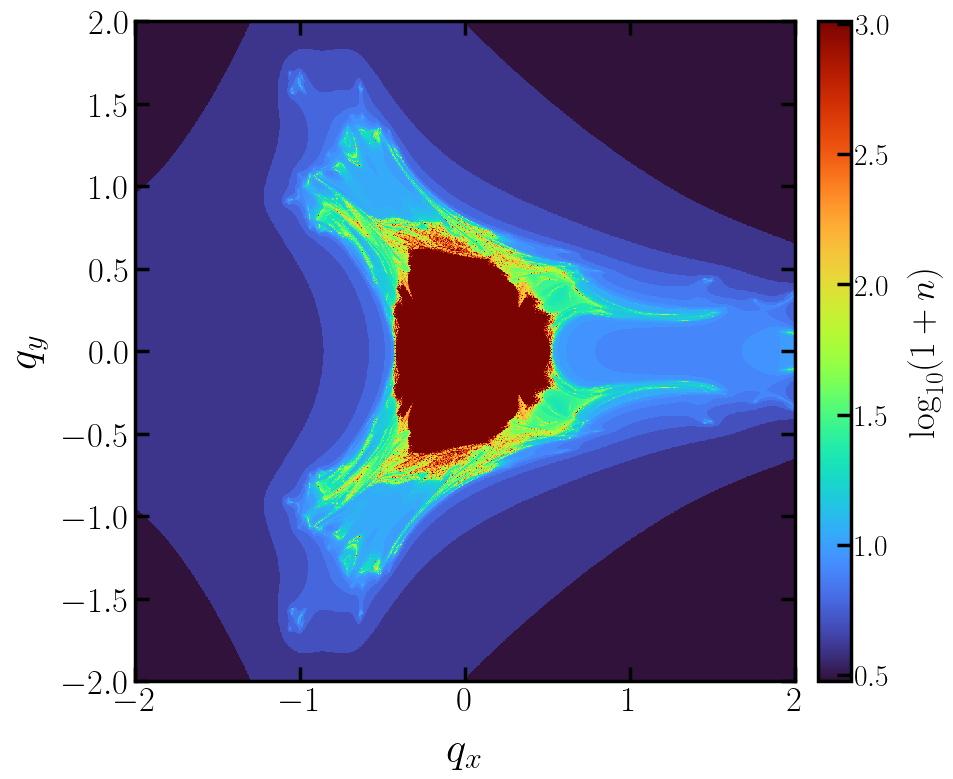

In [145]:
# Plot survival map (inverse)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + result_inverse.reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()

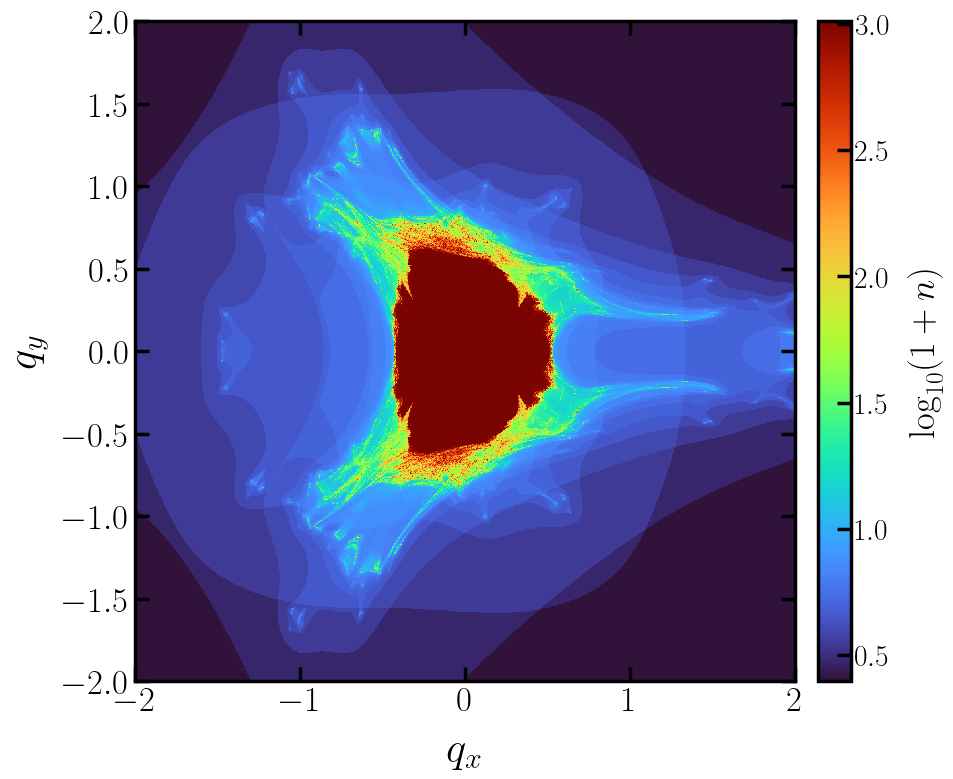

In [146]:
# Plot survival map (combined)

fs = 25
spine_width = 2.5
tick_width = 2.5
tick_length = 10
dpi = 300

data = np.log10(1.0 + 1/2*(result + result_inverse).reshape(m, m))

fig, ax = plt.subplots(figsize=(9.0, 8.0))
fig.subplots_adjust(left=0.150, right=0.975, bottom=0.150, top=0.975)
image = ax.imshow(data, origin="lower", extent=(-2.0, 2.0, -2.0, 2.0), cmap="turbo", interpolation="nearest", aspect="equal")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$q_x$", fontsize=1.25 * fs, labelpad=10)
ax.set_ylabel(r"$q_y$", fontsize=1.25 * fs, labelpad=10)
ax.tick_params(axis="both", which="major", width=tick_width, length=tick_length, direction="in", labelsize=fs, top=True, right=True)
ax.tick_params(axis="both", which="minor", width=0.75 * tick_width, length=0.75 * tick_length, direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(spine_width)
bar = fig.colorbar(image, ax=ax, orientation="vertical", pad=0.03, fraction=0.046)
bar.set_label(r"$\log_{10}(1+n)$", fontsize=1.05 * fs, labelpad=12)
bar.ax.tick_params(width=tick_width, length=tick_length, direction="in", labelsize=0.85 * fs)
bar.outline.set_linewidth(spine_width)
plt.show()